In [1]:
import subprocess
import json
import os
import math
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import numbers
import tempfile
import matplotlib.gridspec as gridspec
from pyproj import Transformer
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
from scipy.spatial.distance import directed_hausdorff
from shapely.validation import make_valid

In [2]:
source_and_destination = "NHD"

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
java_jar = os.path.join(repo_root, "demo", "target", "quickstart-0.0.1-SNAPSHOT.jar")
input_geojson = os.path.join(repo_root, "data", source_and_destination, "NHDFlowline.geojson")
output_dir = os.path.join(repo_root, "output", "dataset_test_results", source_and_destination)
java_dir = os.path.join(repo_root, "demo")

In [4]:
def get_top_n_longest(input_geojson, output_geojson=None, crs_utm=None):
    gdf = gpd.read_file(input_geojson)
    gdf = gdf[gdf.geometry.notna() & gdf.geometry.is_valid]
    
    gdf['vertex_count'] = gdf.geometry.apply(lambda g: len(g.coords))
    top_n = gdf.nlargest(1000, 'vertex_count').drop(columns=['vertex_count']).reset_index(drop=True)

    if output_geojson:
        os.makedirs(os.path.dirname(output_geojson), exist_ok=True)
        top_n.to_file(output_geojson, driver='GeoJSON')
        print("saved!")

    return top_n

sampled_geojson = os.path.join(output_dir, "sampled_1000_longest.geojson")
sampled_gdf = get_top_n_longest(input_geojson, sampled_geojson, crs_utm="EPSG:32648")

saved!


In [5]:
def build_simplification_code():
    mvn_path = shutil.which("mvn.cmd") or shutil.which("mvn")

    cmd = f'"{mvn_path}" clean package -q'
    
    result = subprocess.run(
        cmd,
        cwd=java_dir,
        shell=True,
        capture_output=True,
        text=True,
        env=os.environ.copy()
    )

    if result.returncode == 0:
        print("success!")
        return True
    else:
        print("Build failed!")
        print(result.stdout)
        print(result.stderr)
        return False

def run_simplification(epsilon, use_sample=False):
    if not build_simplification_code():
        return False
    
    os.makedirs(output_dir, exist_ok=True)

    current_input = sampled_geojson if use_sample else input_geojson

    cmd = [
        "java", "-jar", java_jar,
        current_input, output_dir, str(epsilon)
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=repo_root)

    if result.returncode != 0:
        print("Error at simplification!", result.stderr)
    else:
        print("Output:", output_dir)

run_simplification(150, use_sample=True)

success!
Output: C:\Users\MyLaptop\Documents\Tugas Akhir\kode\Tugas_Akhir\output\dataset_test_results\NHD


Original UTM CRS: EPSG:4326


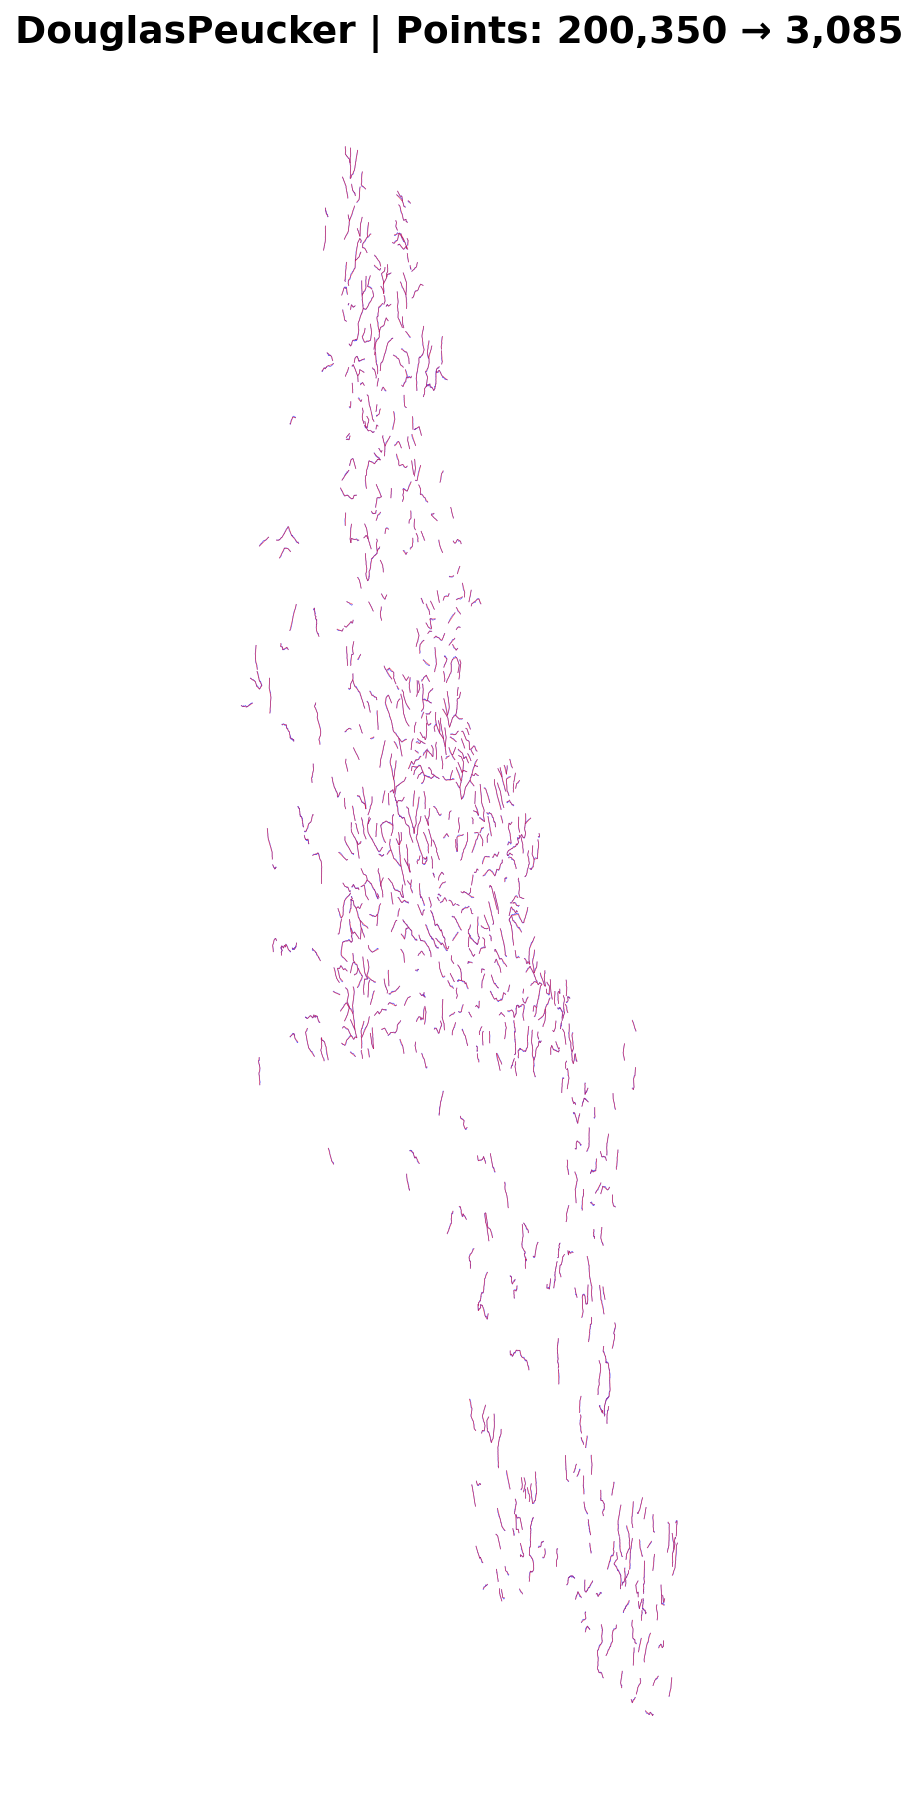

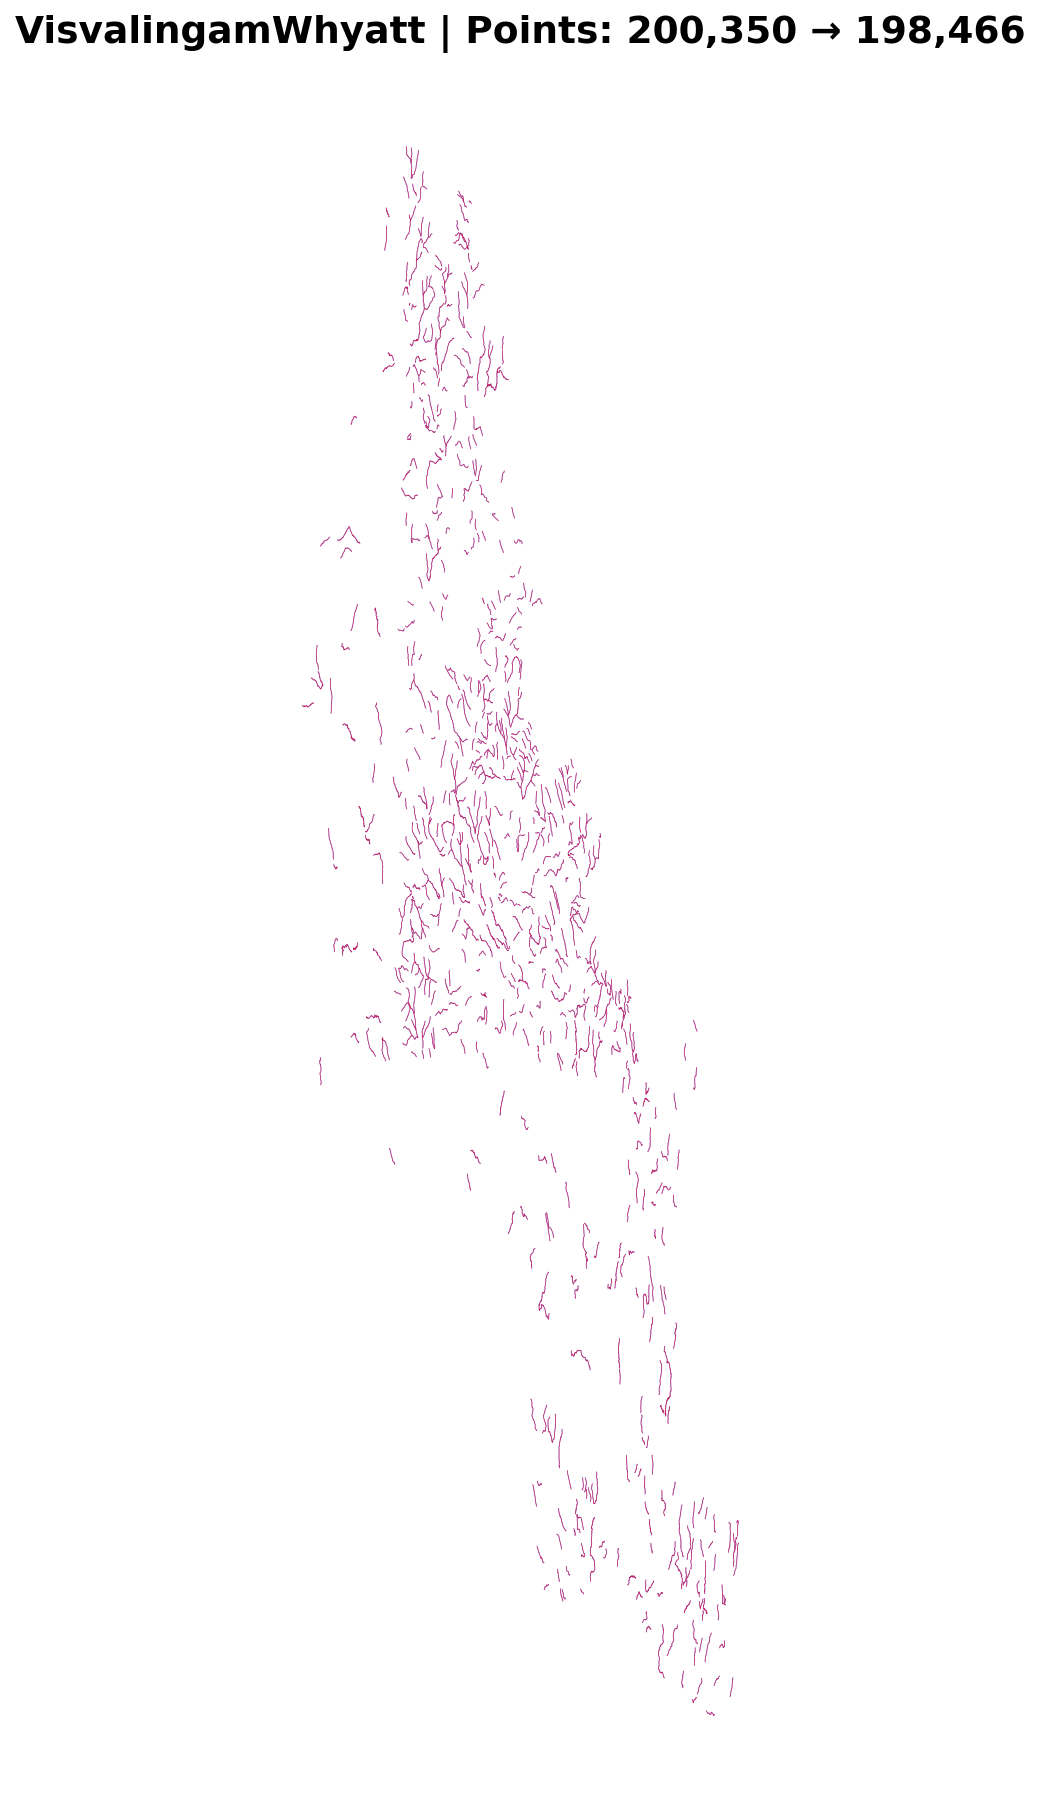

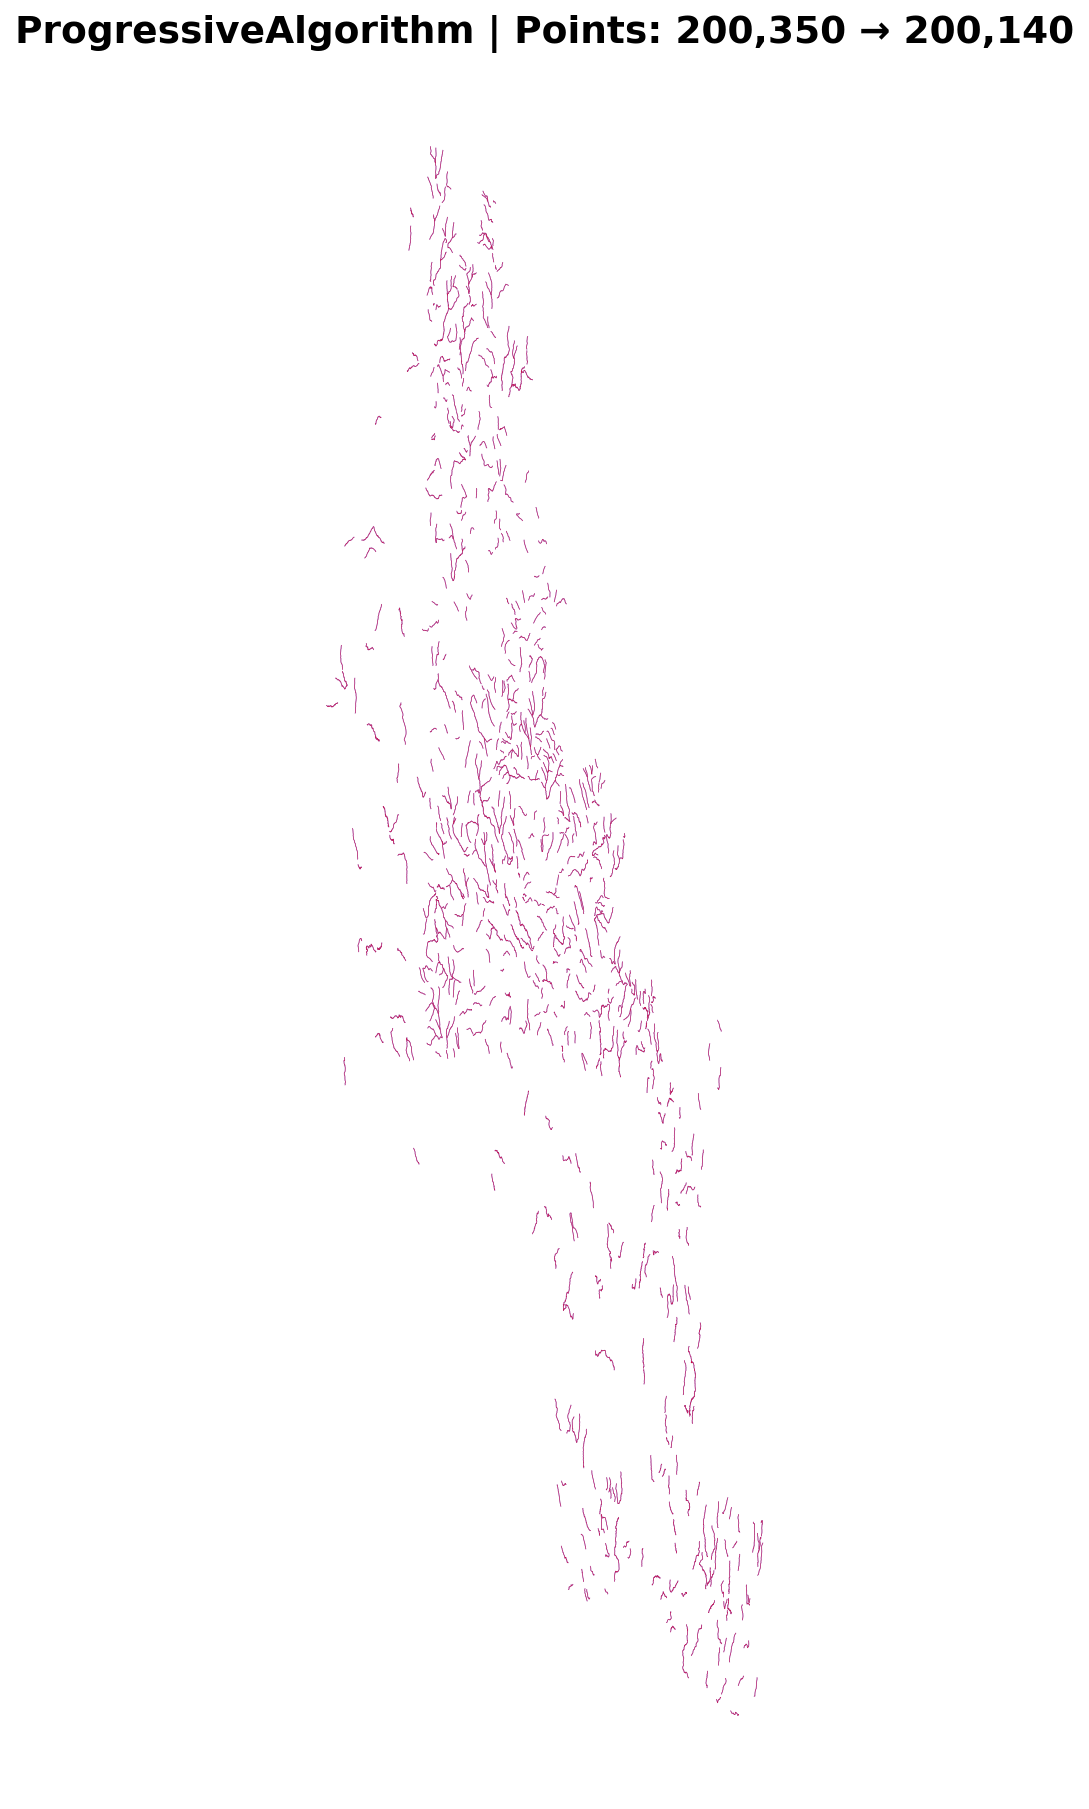

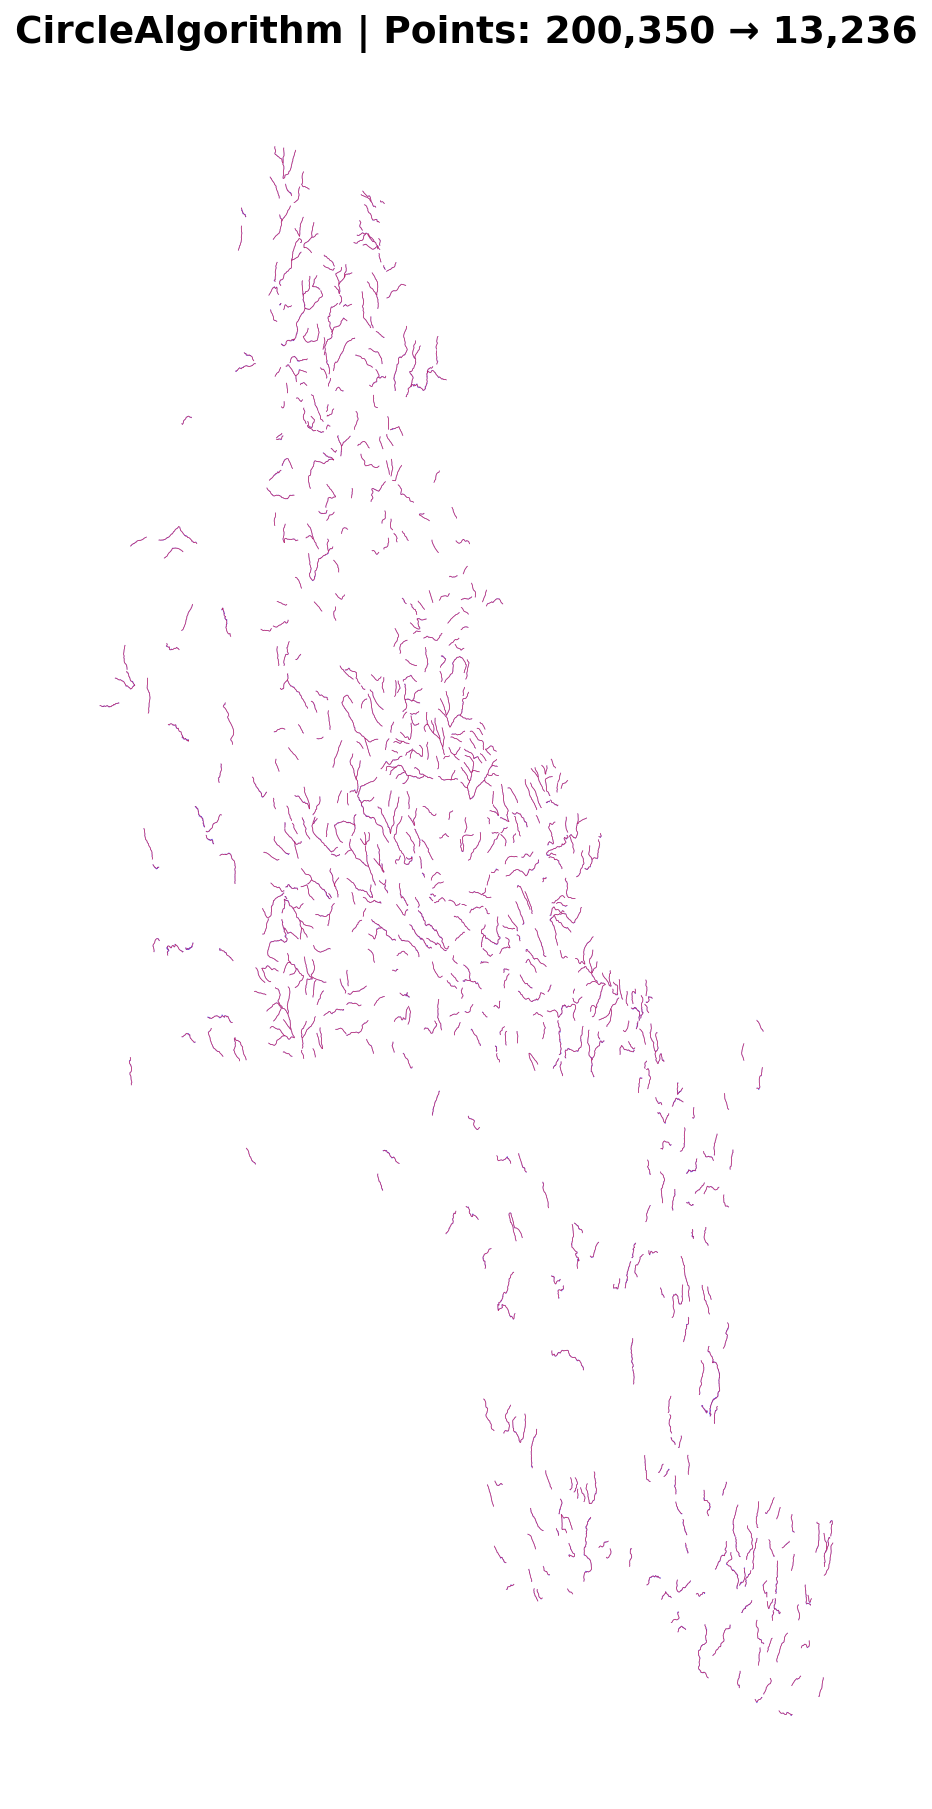

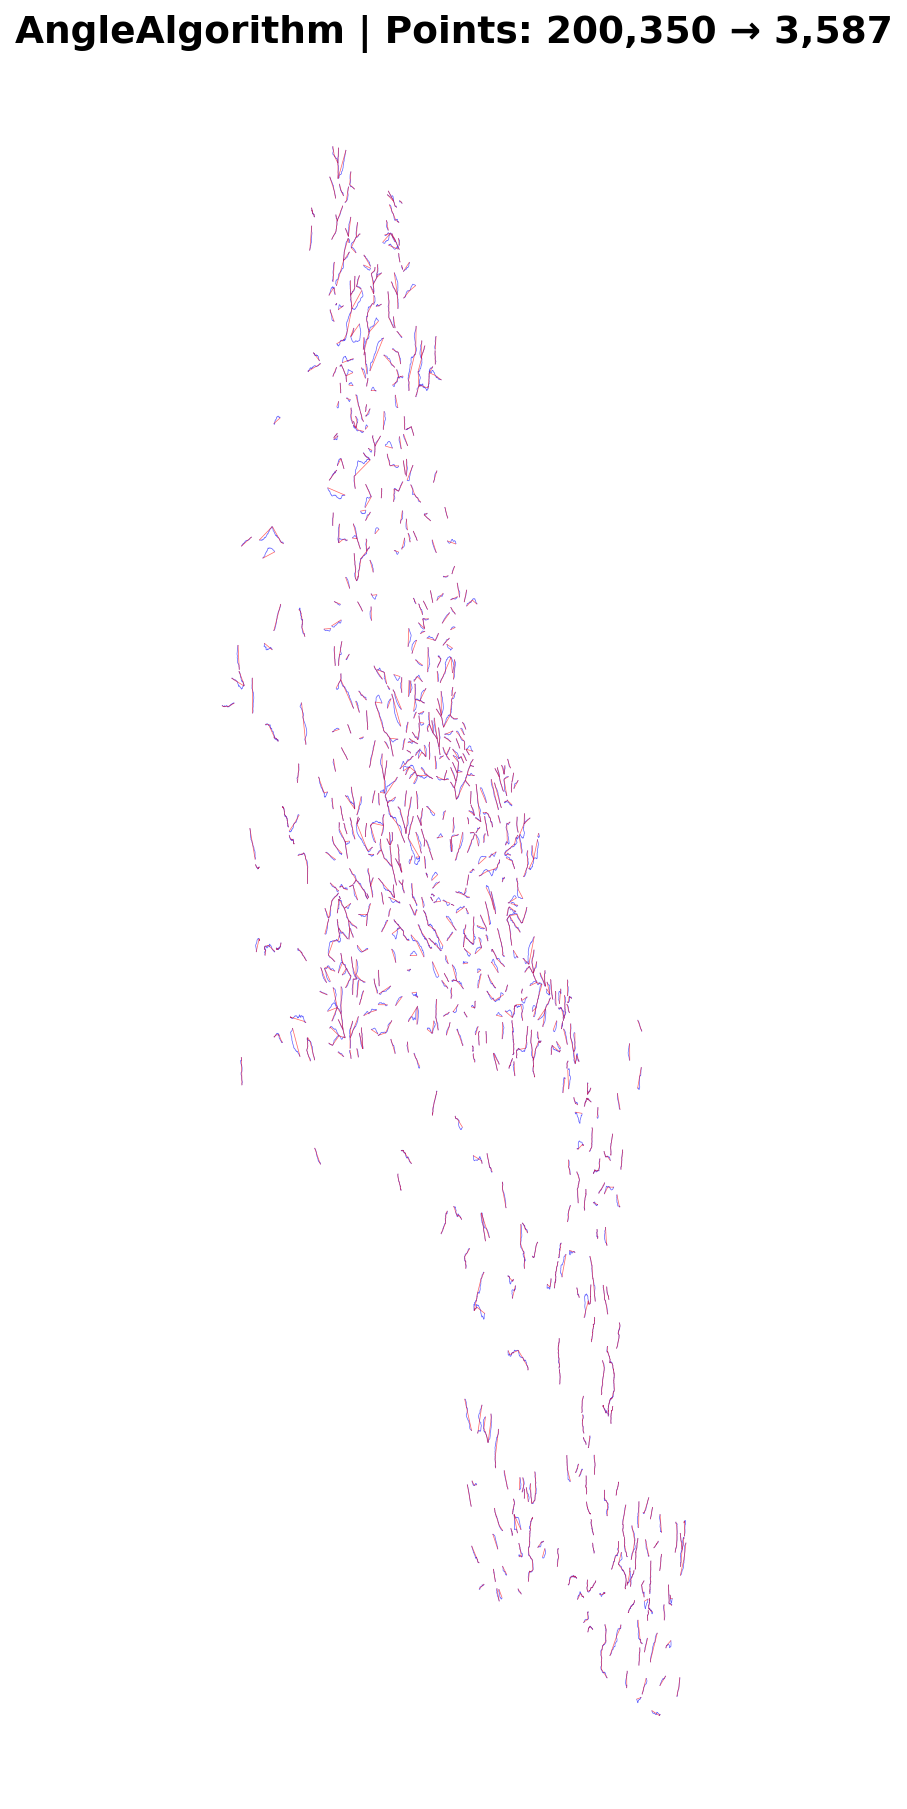

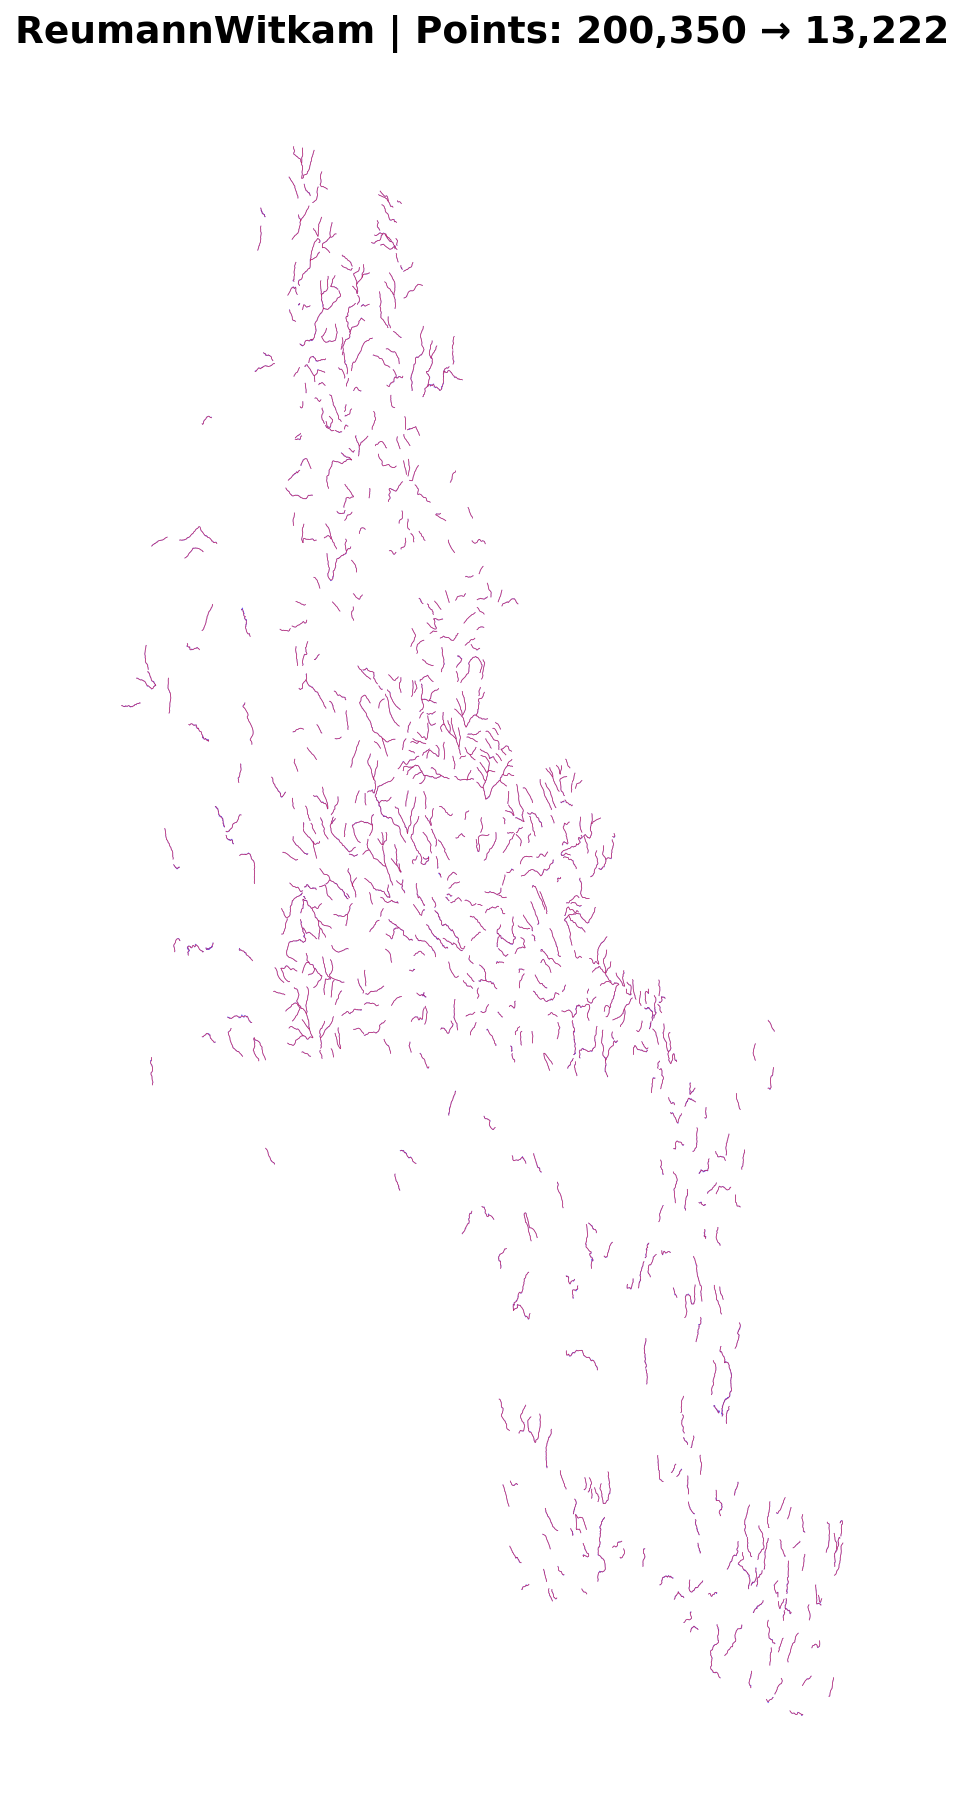

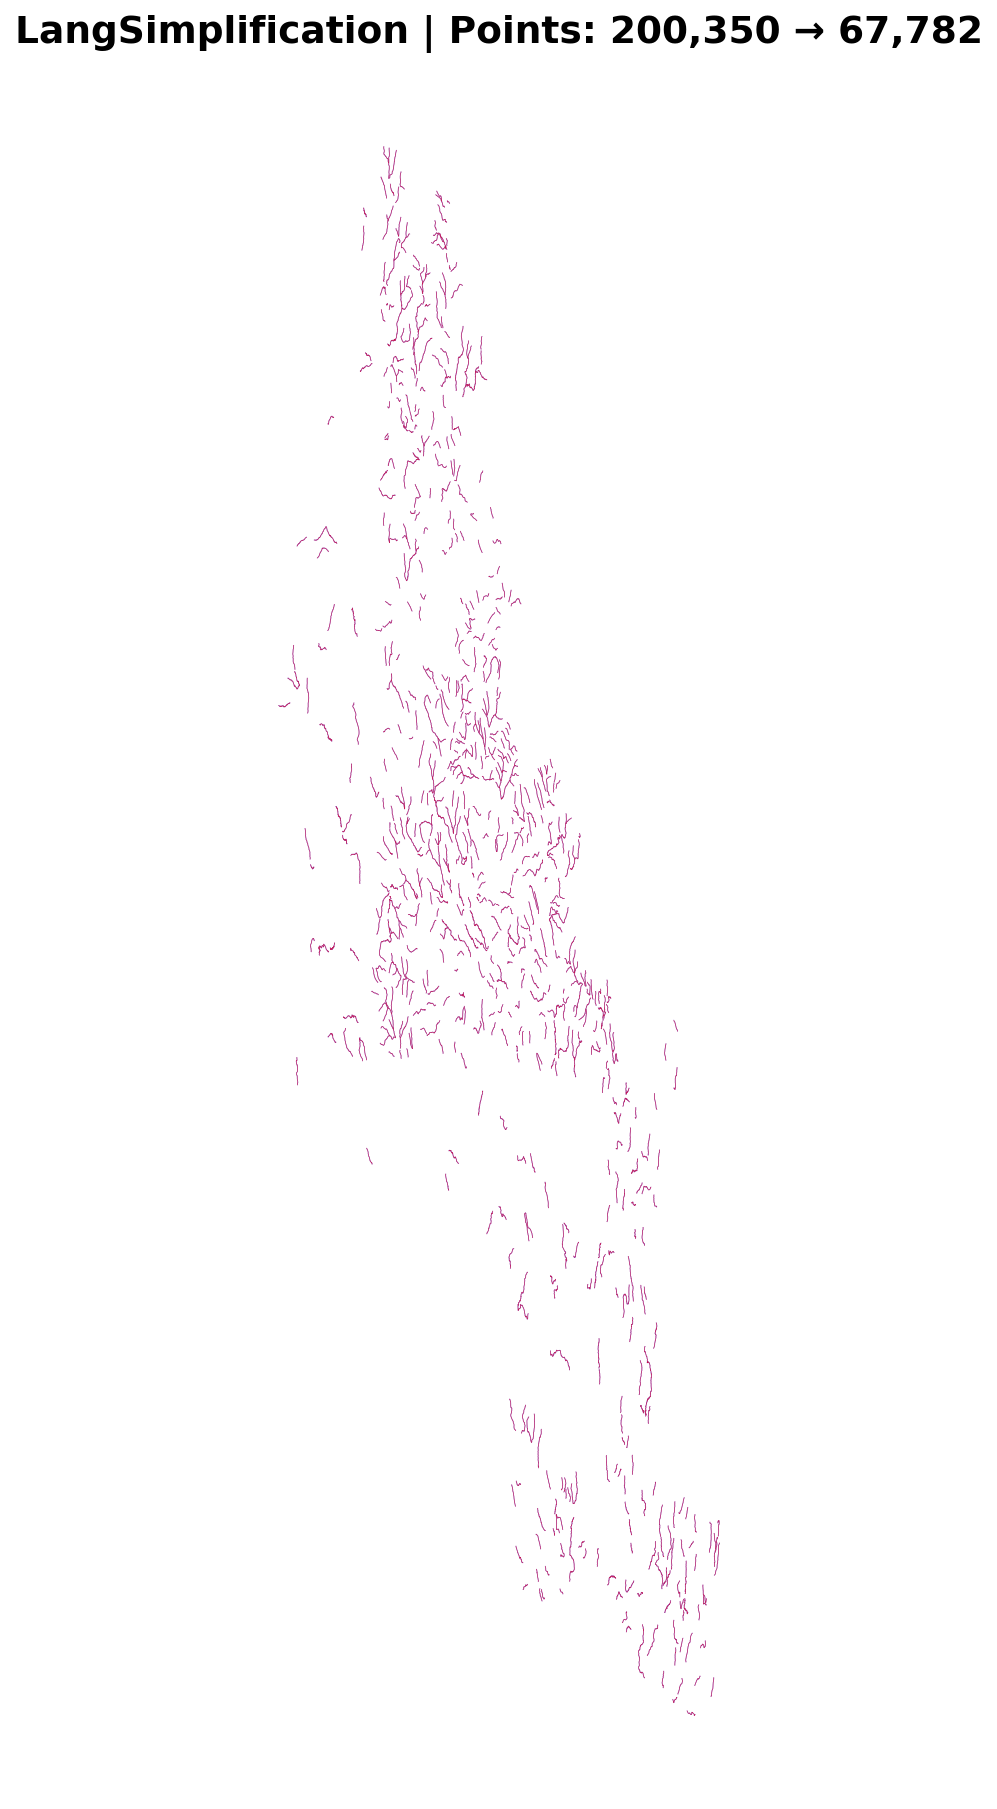

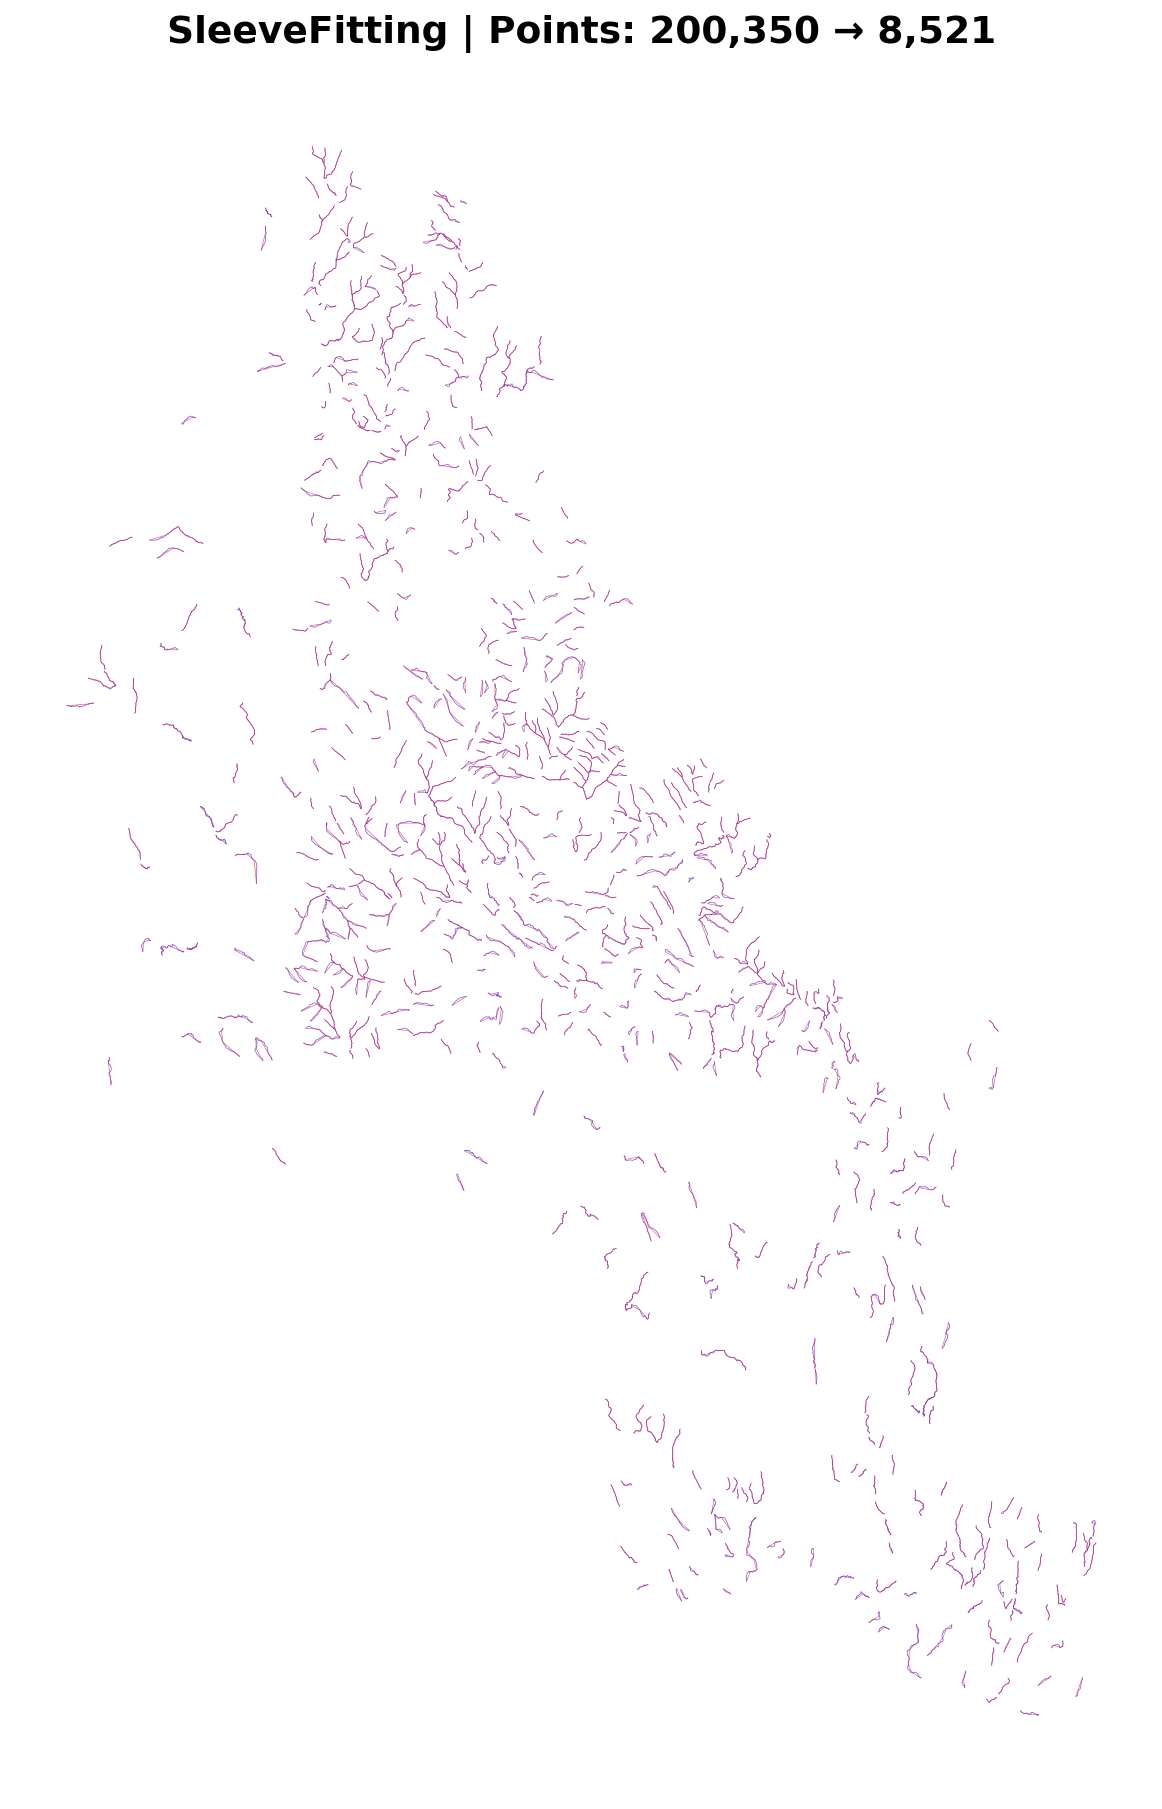

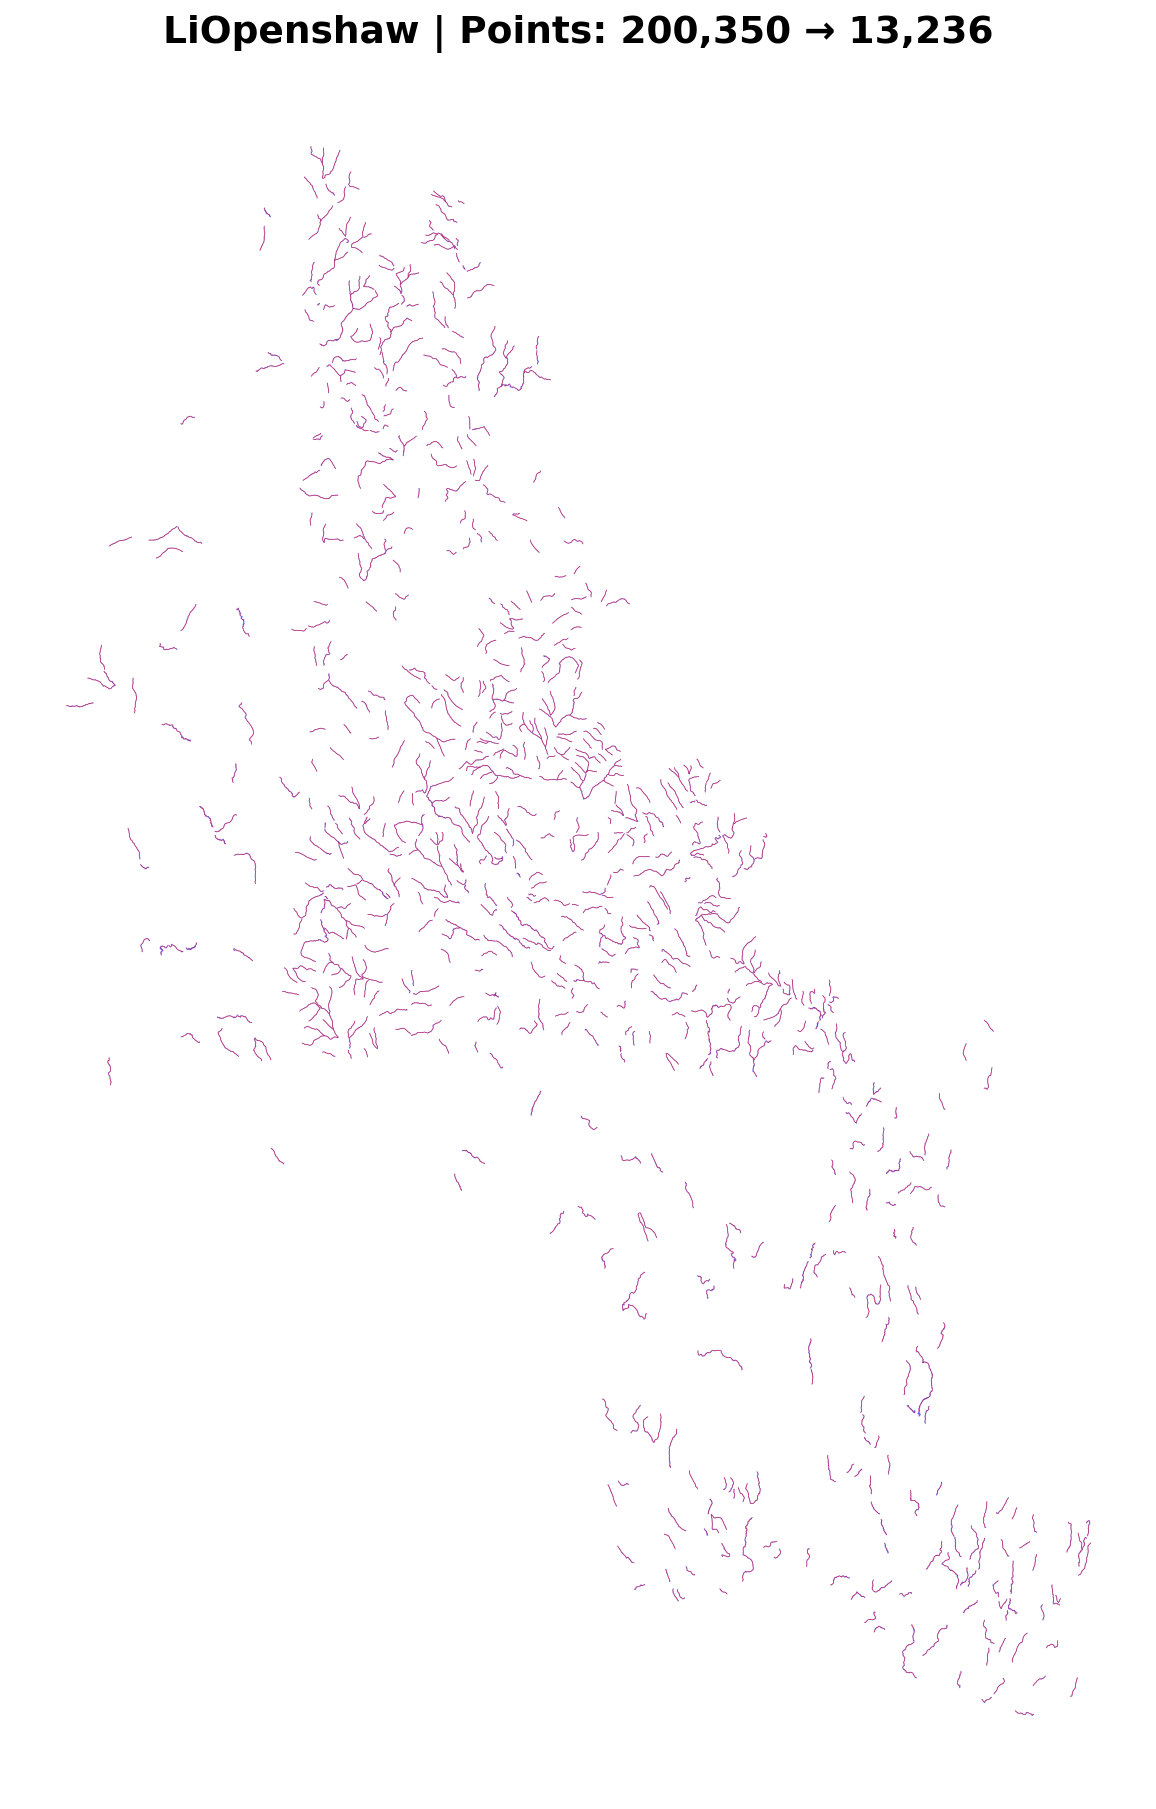

In [6]:
algorithms = [
    "DouglasPeucker",
    "VisvalingamWhyatt",
    "ProgressiveAlgorithm",
    "CircleAlgorithm",
    "AngleAlgorithm",
    "ReumannWitkam",
    "LangSimplification",
    "SleeveFitting",
    "LiOpenshaw"
]

original_gdf = gpd.read_file(os.path.join(output_dir, "reprojected_dataset.geojson"))
print(f"Original UTM CRS: {original_gdf.crs}")

simplified_gdfs = {}
for algo in algorithms:
    path = os.path.join(output_dir, f"{algo}.geojson")
    if os.path.exists(path):
        gdf = gpd.read_file(path)

        if gdf.crs != original_gdf.crs:
            print("CRS doesn't match!")
            gdf = gdf.to_crs(original_gdf.crs)
        simplified_gdfs[algo] = gdf
    else:
        print("geojson not found.")

plt.rcParams['figure.dpi'] = 150 

for idx, algo in enumerate(algorithms):
    if algo not in simplified_gdfs:
        print(f"Skipping {algo} — no data")
        continue

    gdf_simplified = simplified_gdfs[algo]
    
    fig, ax = plt.subplots(figsize=(18, 12))  

    original_gdf.plot(ax=ax, color='blue', linewidth=0.35, alpha=0.6, zorder=1, label="Original")
    gdf_simplified.plot(ax=ax, color='red', linewidth=0.35, alpha=0.6, zorder=2, label="Simplified")

    ax.autoscale()
    
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    orig_points = sum(len(geom.coords) for geom, geom, in zip(original_gdf.geometry, original_gdf.geometry) if geom.geom_type == 'LineString')
    simp_points = sum(len(geom.coords) for geom, geom in zip(gdf_simplified.geometry, gdf_simplified.geometry) if geom.geom_type == 'LineString')

    ax.set_title(
        f"{algo} | Points: {orig_points:,} → {simp_points:,}",
        fontsize=18, weight='bold', pad=12
    )
    
    plt.tight_layout(pad=0.5)
    plt.show()

In [7]:
def ccw_orientation(a, b, c):
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def segments_intersect(p1, p2, p3, p4):
    if p1 == p2 or p3 == p4:
        return false

    d1 = ccw_orientation(p3, p4, p1)
    d2 = ccw_orientation(p3, p4, p2)
    d3 = ccw_orientation(p1, p2, p3)
    d4 = ccw_orientation(p1, p2, p4)

    if ((d1 > 0 and d2 < 0) or (d1 < 0 and d2 > 0)) and ((d3 > 0 and d4 < 0) or (d3 < 0 and d4 > 0)):
        return True

    if d1 == 0 and min(p3[0], p4[0]) <= p1[0] <= max(p3[0], p4[0]) and min(p3[1], p4[1]) <= p1[1] <= max(p3[1], p4[1]):
        return True
    if d2 == 0 and min(p3[0], p4[0]) <= p2[0] <= max(p3[0], p4[0]) and min(p3[1], p4[1]) <= p2[1] <= max(p3[1], p4[1]):
        return True
    if d3 == 0 and min(p1[0], p2[0]) <= p3[0] <= max(p1[0], p2[0]) and min(p1[1], p2[1]) <= p3[1] <= max(p1[1], p2[1]):
        return True
    if d4 == 0 and min(p1[0], p2[0]) <= p4[0] <= max(p1[0], p2[0]) and min(p1[1], p2[1]) <= p4[1] <= max(p1[1], p2[1]):
        return True
        
    return False

def point_to_segment_dist(point, start, end):
    p = np.array(point, dtype=float)
    a = np.array(start, dtype=float)
    b = np.array(end, dtype=float)

    ab = b - a
    ap = p - a

    ab_len_sq = np.dot(ab, ab)
    if ab_len_sq == 0.0:
        return np.lialg.norm(ap)

    t = np.dot(ap, ab) / ab_len_sq

    if t < 0.0:
        return np.linalg.norm(p - a)
    elif t > 1.0:
        return np.linalg.norm(p - b)
    else:
        cross_product = np.abs(ab[0] * ap[1] - ab[1] * ap[0])
        return cross_product / np.sqrt(ab_len_sq)

def calc_angle(v_prev, v_curr, v_next):
    v_prev = np.array(v_prev)
    v_curr = np.array(v_curr)
    v_next = np.array(v_next)

    v_in = v_prev - v_curr
    v_out = v_next - v_curr

    norm_in = np.linalg.norm(v_in)
    norm_out = np.linalg.norm(v_out)

    if norm_in == 0 or norm_out == 0:
        return 180.0

    v_in_norm = v_in / norm_in
    v_out_norm = v_out / norm_out

    cos_angle = np.clip(np.dot(v_in_norm, v_out_norm), -1.0, 1.0)
    angle_rad = math.acos(cos_angle)
    angle_deg = math.degrees(angle_rad)

    return angle_deg

def calc_angular_feature_retention(original_gdf, simplified_gdf, percentile_threshold=75):
    important_vertices = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    if min_len == 0:
        return 1.0

    all_angles = []
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        if orig_line is None or len(orig_line.coords) < 3:
            continue

        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            angle = calc_angle(coords[i-1], coords[i], coords[i+1])
            all_angles.append(angle)

    if not all_angles:
        return 1.0

    threshold = np.percentile(all_angles, percentile_threshold)

    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        if orig_line is None or len(orig_line.coords) < 3:
            continue

        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            angle = calc_angle(coords[i-1], coords[i], coords[i+1])

            if angle >= threshold:
                important_vertices.append((round(float(coords[i][0]), 6), round(float(coords[i][1]), 6)))

    if not important_vertices:
        return 1.0

    simplified_vertices = set()
    for idx in range(len(simplified_gdf)):
        simp_line = simplified_gdf.iloc[idx].geometry
        
        if simp_line is None:
            continue

        for coord in simp_line.coords:
            simplified_vertices.add((round(float(coord[0]), 6), round(float(coord[1]), 6)))

    retained_count = 0
    for vertex in important_vertices:
        if vertex in simplified_vertices:
            retained_count += 1

    return retained_count / len(important_vertices)

def segment_hausdorff_dist(line_a, line_b):
    coords_a = list(line_a.coords)
    coords_b = list(line_b.coords)

    if len(coords_a) < 2 or len(coords_b) < 2:
        return float('inf')

    segments_b = [(coords_b[i], coords_b[i+1]) for i in range(len(coords_b) - 1)]
    segments_a = [(coords_a[i], coords_a[i+1]) for i in range(len(coords_a) - 1)]

    max_dist_a_to_b = 0.0
    for pt in coords_a:
        min_dist = min(point_to_segment_dist(pt, seg[0], seg[1]) for seg in segments_b)
        max_dist_a_to_b = max(max_dist_a_to_b, min_dist)

    max_dist_b_to_a = 0.0
    for pt in coords_b:
        min_dist = min(point_to_segment_dist(pt, seg[0], seg[1]) for seg in segments_a)
        max_dist_b_to_a = max(max_dist_b_to_a, min_dist)

    return max(max_dist_a_to_b, max_dist_b_to_a)

def calc_segment_hausdorff(original_gdf, simplified_gdf):
    distances = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        if orig_line is None or simp_line is None:
            continue

        try:
            dist = segment_hausdorff_dist(orig_line, simp_line)
            if np.isfinite(dist):
                distances.append(dist)
        except:
            continue

    return np.mean(distances) if distances else 0.0
        
def hausdorff_dist(original_gdf, simplified_gdf):
    distances = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        coords1 = np.array(orig_line.coords)
        coords2 = np.array(simp_line.coords)

        if len(coords1) < 2 or len(coords2) < 2:
            continue

        try:
            h1 = directed_hausdorff(coords1, coords2)[0]
            h2 = directed_hausdorff(coords2, coords1)[0]
            hausdorff_distance = max(h1, h2)

            distances.append(hausdorff_distance)
        except:
            continue

    return np.mean(distances) if distances else 0.0

def triangle_area(v_prev, v_curr, v_next):
    prev = np.array(v_prev)
    curr = np.array(v_curr)
    next_pt = np.array(v_next)

    vec1 = curr - prev
    vec2 = next_pt - prev

    cross_product = vec1[0] * vec2[1] - vec1[1] * vec2[0]

    area = 0.5 * abs(cross_product)
    return area

def calc_semantic_retention(original_gdf, simplified_gdf, percentile_threshold=75, tolerance=10.0):
    min_len = min(len(original_gdf), len(simplified_gdf))
    
    all_areas = []
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        if orig_line is None or len(orig_line.coords) < 3:
            continue
        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            area = triangle_area(coords[i-1], coords[i], coords[i+1])
            all_areas.append(area)
    
    threshold = np.percentile(all_areas, percentile_threshold)
    
    important_vertices_orig = []
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        
        if len(orig_line.coords) < 3:
            continue
            
        coords = list(orig_line.coords)
        for i in range(1, len(coords) - 1):
            area = triangle_area(coords[i-1], coords[i], coords[i+1])
            if area >= threshold:
                important_vertices_orig.append((float(coords[i][0]), float(coords[i][1])))
    
    if not important_vertices_orig:
        return 1.0
    
    simplified_vertices = set()
    for idx in range(len(simplified_gdf)):
        simp_line = simplified_gdf.iloc[idx].geometry
        
        for coord in simp_line.coords:
            simplified_vertices.add((round(float(coord[0]), 6), round(float(coord[1]), 6)))
    
    retained_count = 0
    for vertex in important_vertices_orig:
        rounded_vertex = (round(vertex[0], 6), round(vertex[1], 6))
        
        if rounded_vertex in simplified_vertices:
            retained_count += 1
    
    return retained_count / len(important_vertices_orig)

def frechet_dist(P, Q):
    def c(ca, i, j, P, Q):
        if ca[i, j] > -1:
            return ca[i, j]
        elif i == 0 and j == 0:
            ca[i, j] = np.linalg.norm(P[0] - Q[0])
        elif i > 0 and j == 0:
            ca[i, j] = max(c(ca, i-1, 0, P, Q), np.linalg.norm(P[i] - Q[0]))
        elif i == 0 and j > 0:
            ca[i, j] = max(c(ca, 0, j-1, P, Q), np.linalg.norm(P[0] - Q[j]))
        elif i > 0 and j > 0:
            ca[i, j] = max(
                min(c(ca, i-1, j, P, Q), c(ca, i-1, j-1, P, Q), c(ca, i, j-1, P, Q)),
                np.linalg.norm(P[i] - Q[j])
            )
        else:
            ca[i, j] = float('inf')
        return ca[i, j]

    P = np.array(P)
    Q = np.array(Q)

    if len(P) == 0 or len(Q) == 0:
        return float('inf')

    ca = np.ones((len(P), len(Q))) * -1
    return c(ca, len(P)-1, len(Q)-1, P, Q)

def calc_shape_preservation(original_gdf, simplified_gdf):
    distances = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        if orig_line is None or simp_line is None:
            continue

        orig_coords = list(orig_line.coords)
        simp_coords = list(simp_line.coords)

        if len(orig_coords) < 2 or len(simp_coords) < 2:
            continue

        try:
            f_dist = frechet_dist(orig_coords, simp_coords)
            distances.append(f_dist)
        except:
            continue

    return np.mean(distances) if distances else 0.0

def ddtw_distance(P, Q):
    P = np.array(P)
    Q = np.array(Q)
    n, m = len(P), len(Q)

    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(P[i-1] - Q[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])

    return dtw[n, m]

def calc_dtw_metric(original_gdf, simplified_gdf):
    distances = []
    
    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry
        
        if orig_line is None or simp_line is None:
            continue
            
        orig_coords = list(orig_line.coords)
        simp_coords = list(simp_line.coords)
        
        if len(orig_coords) < 2 or len(simp_coords) < 2:
            continue
            
        try:
            d_dist = ddtw_distance(orig_coords, simp_coords)
            distances.append(d_dist)
        except:
            continue
    
    return np.mean(distances) if distances else 0.0

def lcss(P, Q, eps=50.0):
    P = np.array(P)
    Q = np.array(Q)
    n, m = len(P), len(Q)
    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if np.linalg.norm(P[i-1] - Q[j-1]) <= eps:
                dp[i, j] = dp[i-1, j-1] + 1
            else:
                dp[i, j] = max(dp[i-1, j], dp[i, j-1])
                
    return dp[n, m] / min(n, m) if min(n, m) > 0 else 0.0

def calc_lcss_similarity(original_gdf, simplified_gdf, eps=50.0):
    similarities = []
    
    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry
        
        if orig_line is None or simp_line is None:
            continue
            
        orig_coords = list(orig_line.coords)
        simp_coords = list(simp_line.coords)
        
        if len(orig_coords) < 2 or len(simp_coords) < 2:
            continue
            
        try:
            l_sim = lcss_similarity(orig_coords, simp_coords, eps)
            similarities.append(l_sim)
        except:
            continue
    
    return np.mean(similarities) if similarities else 0.0

def count_self_intersection(coords):
    if len(coords) < 4:
        return 0

    intersections = 0
    n = len(coords)

    for i in range(n - 1):
        for j in range(i + 2, n - 1):
            if j == i + 1:
                continue

            p1, p2 = coords[i], coords[i + 1]
            p3, p4 = coords[j], coords[j + 1]

            if segments_intersect(p1, p2, p3, p4):
                intersections += 1

    return intersections

def calc_topological_validity(simplified_gdf):
    if len(simplified_gdf) == 0:
        return 1.0

    intersection_counts = []

    for geom in simplified_gdf.geometry:
        if geom is None or not isinstance(geom, LineString):
            intersection_counts.append(0)
            continue

        coords = list(geom.coords)
        if len(coords) < 4:
            intersection_counts.append(0)
            continue

        count = count_self_intersection(coords)
        intersection_counts.append(count)

    if not intersection_counts:
        return 1.0

    mean_intersections = np.mean(intersection_counts)
    score = 1.0 / (1.0 + mean_intersections)
    return score

def calc_circular_coverage(original_gdf, simplified_gdf, buffer_radius):
    coverage_ratios = []

    min_len = min(len(original_gdf), len(simplified_gdf))
    for idx in range(min_len):
        orig_line = original_gdf.iloc[idx].geometry
        simp_line = simplified_gdf.iloc[idx].geometry

        if orig_line is None or simp_line is None:
            continue

        try:
            simp_buffer = simp_line.buffer(buffer_radius)
            intersection = orig_line.intersection(simp_buffer)

            if intersection.is_empty:
                convered_length = 0.0
            else:
                if intersection.geom_type == 'LineString':
                    covered_length = intersection.length
                elif intersection.geom_type == 'MultiLineString':
                    covered_length = sum(seg.length for seg in intersection.geoms)
                else:
                    covered_length = 0.0

            total_length = orig_line.length
            if total_length > 0:
                coverage_ratio = covered_length / total_length
                coverage_ratios.append(coverage_ratio)
        except:
            coverage_ratios.append(0.0)

    return np.mean(coverage_ratios) if coverage_ratios else 0.0 

def calc_D_ground(scale, h_res=1920, v_res=1080, screen_diag_inches=15.6, observe_dist_mm=600):
    PPI = np.sqrt(h_res**2 + v_res**2) / screen_diag_inches
    D_pixel = 0.0254 / PPI
    N_eye = int(np.ceil(0.1746 * PPI / 25.4))
    D_ground = D_pixel * scale * N_eye
    return float(D_ground)

def calc_avg_offset_dist(orig_geom, simp_geom):
    if orig_geom is None or simp_geom is None:
        return float('inf')
    orig_coords = list(orig_geom.coords)
    if not orig_coords:
        return 0.0
    total_dist = sum(simp_geom.distance(Point(pt)) for pt in orig_coords)
    return total_dist / len(orig_coords)

def calc_visual_consistency(original_gdf, simplified_gdf, D_ground):
    if len(original_gdf) == 0 or len(simplified_gdf) == 0:
        return 0.0

    diffs = []
    min_len = min(len(original_gdf), len(simplified_gdf))

    for idx in range(min_len):
        orig_geom = original_gdf.iloc[idx].geometry
        simp_geom = simplified_gdf.iloc[idx].geometry

        if orig_geom is None or simp_geom is None:
            continue

        avg_offset = calc_avg_offset_dist(orig_geom, simp_geom)
        if np.isfinite(avg_offset):
            diff = abs(avg_offset - D_ground)
            diffs.append(diff)

    if not diffs:
        return 0.0

    mean_diff = np.mean(diffs)

    score = max(0.0, 1.0 - (mean_diff / D_ground))
    return float(score)
    

def calc_all_metrics(original_gdf, simplified_gdf):
    TARGET_SCALE = 50000
    D_ground = calc_D_ground(scale=TARGET_SCALE, h_res=1920, v_res=1080, screen_diag_inches=15.6)
    metrics = {}
    
    metrics['hausdorff'] = hausdorff_dist(original_gdf, simplified_gdf)
    metrics['frechet'] = calc_shape_preservation(original_gdf, simplified_gdf)
    metrics['dtw'] = calc_dtw_metric(original_gdf, simplified_gdf)
    metrics['semantic'] = calc_semantic_retention(original_gdf, simplified_gdf)
    metrics['topology'] = calc_topological_validity(simplified_gdf)
    metrics['segment_hausdorff'] = calc_segment_hausdorff(original_gdf, simplified_gdf)
    metrics['circular_coverage'] = calc_circular_coverage(original_gdf, simplified_gdf, 50)
    metrics['angular_retention'] = calc_angular_feature_retention(original_gdf, simplified_gdf, percentile_threshold=75)
    metrics['visual_consistency'] = calc_visual_consistency(original_gdf, simplified_gdf, D_ground)
    
    return metrics

🔹 DouglasPeucker - Raw Metrics:
   hausdorff: 580.7221
   frechet: 580.9586
   dtw: 54424.9959
   semantic: 0.0127
   topology: 1.0000
   segment_hausdorff: 99.7992
   circular_coverage: 0.7114
   angular_retention: 0.0007
   visual_consistency: 0.0000

📊 DouglasPeucker - Normalized Radar Scores:
   hausdorff: 0.472
   frechet: 0.472
   dtw: 0.538
   semantic: 0.013
   topology: 1.000
   segment_hausdorff: 0.686
   circular_coverage: 0.711
   angular_retention: 0.001
   visual_consistency: 1.000



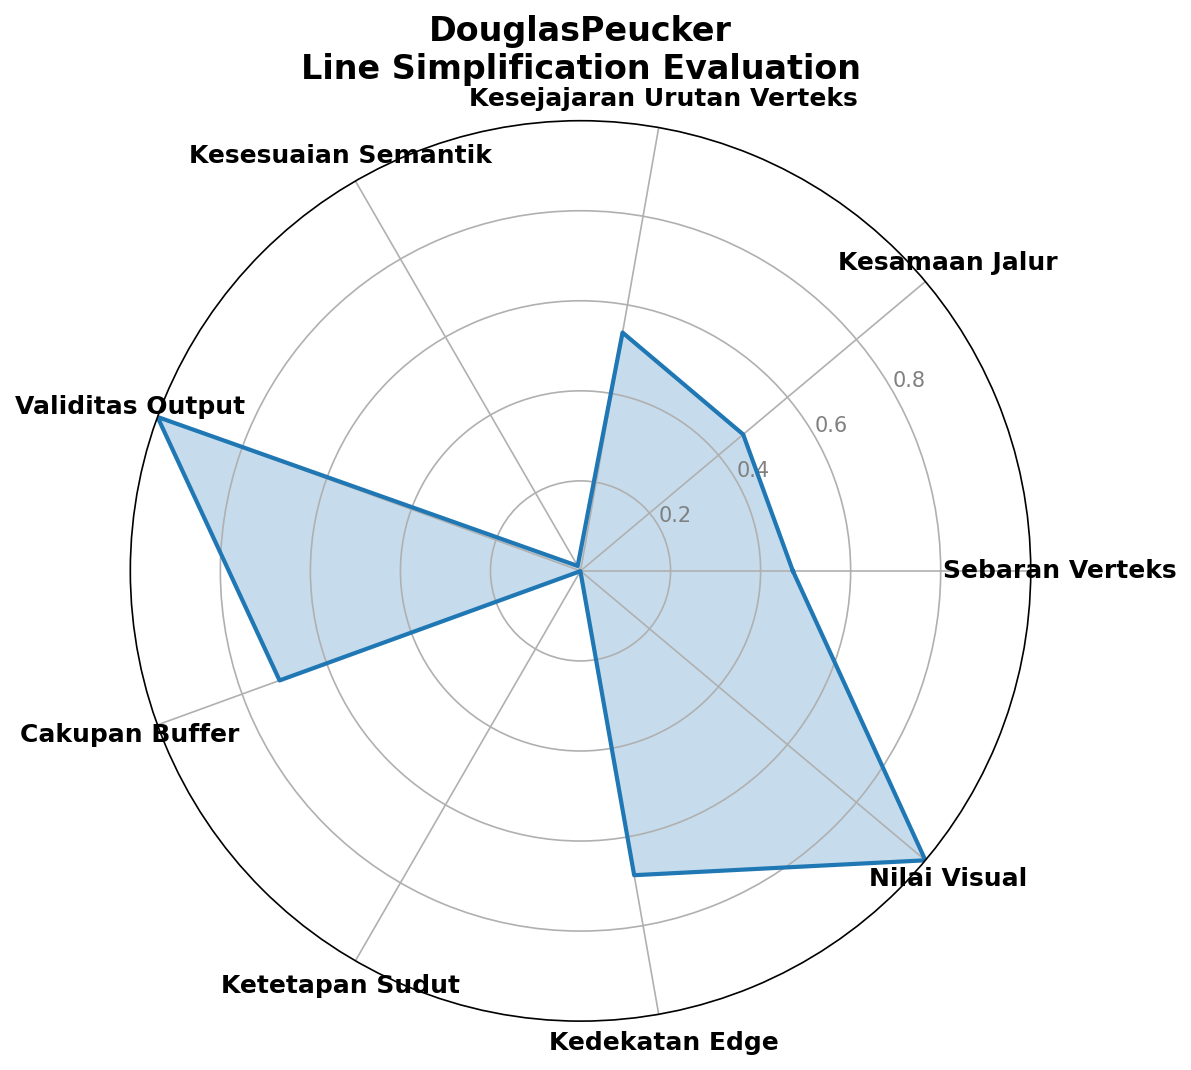




🔹 VisvalingamWhyatt - Raw Metrics:
   hausdorff: 5.1661
   frechet: 5.1661
   dtw: 12.2503
   semantic: 0.9941
   topology: 1.0000
   segment_hausdorff: 0.6735
   circular_coverage: 1.0000
   angular_retention: 0.9874
   visual_consistency: 0.0007

📊 VisvalingamWhyatt - Normalized Radar Scores:
   hausdorff: 0.995
   frechet: 0.995
   dtw: 1.000
   semantic: 0.994
   topology: 1.000
   segment_hausdorff: 0.998
   circular_coverage: 1.000
   angular_retention: 0.987
   visual_consistency: 0.999



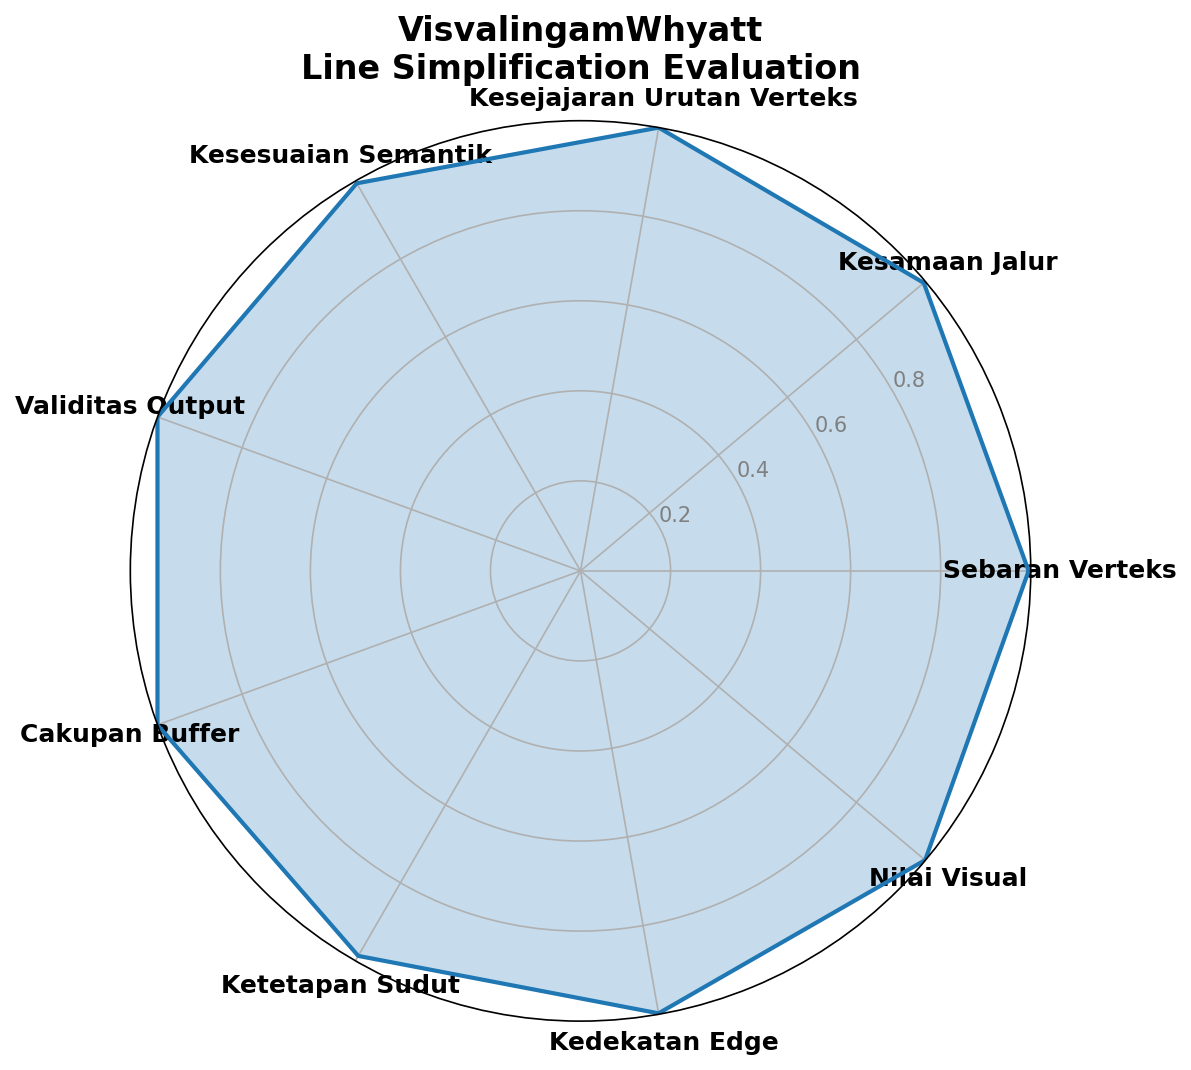




🔹 ProgressiveAlgorithm - Raw Metrics:
   hausdorff: 0.6551
   frechet: 0.6551
   dtw: 0.9304
   semantic: 1.0000
   topology: 1.0000
   segment_hausdorff: 0.0002
   circular_coverage: 1.0000
   angular_retention: 0.9958
   visual_consistency: 0.0000

📊 ProgressiveAlgorithm - Normalized Radar Scores:
   hausdorff: 0.999
   frechet: 0.999
   dtw: 1.000
   semantic: 1.000
   topology: 1.000
   segment_hausdorff: 1.000
   circular_coverage: 1.000
   angular_retention: 0.996
   visual_consistency: 1.000



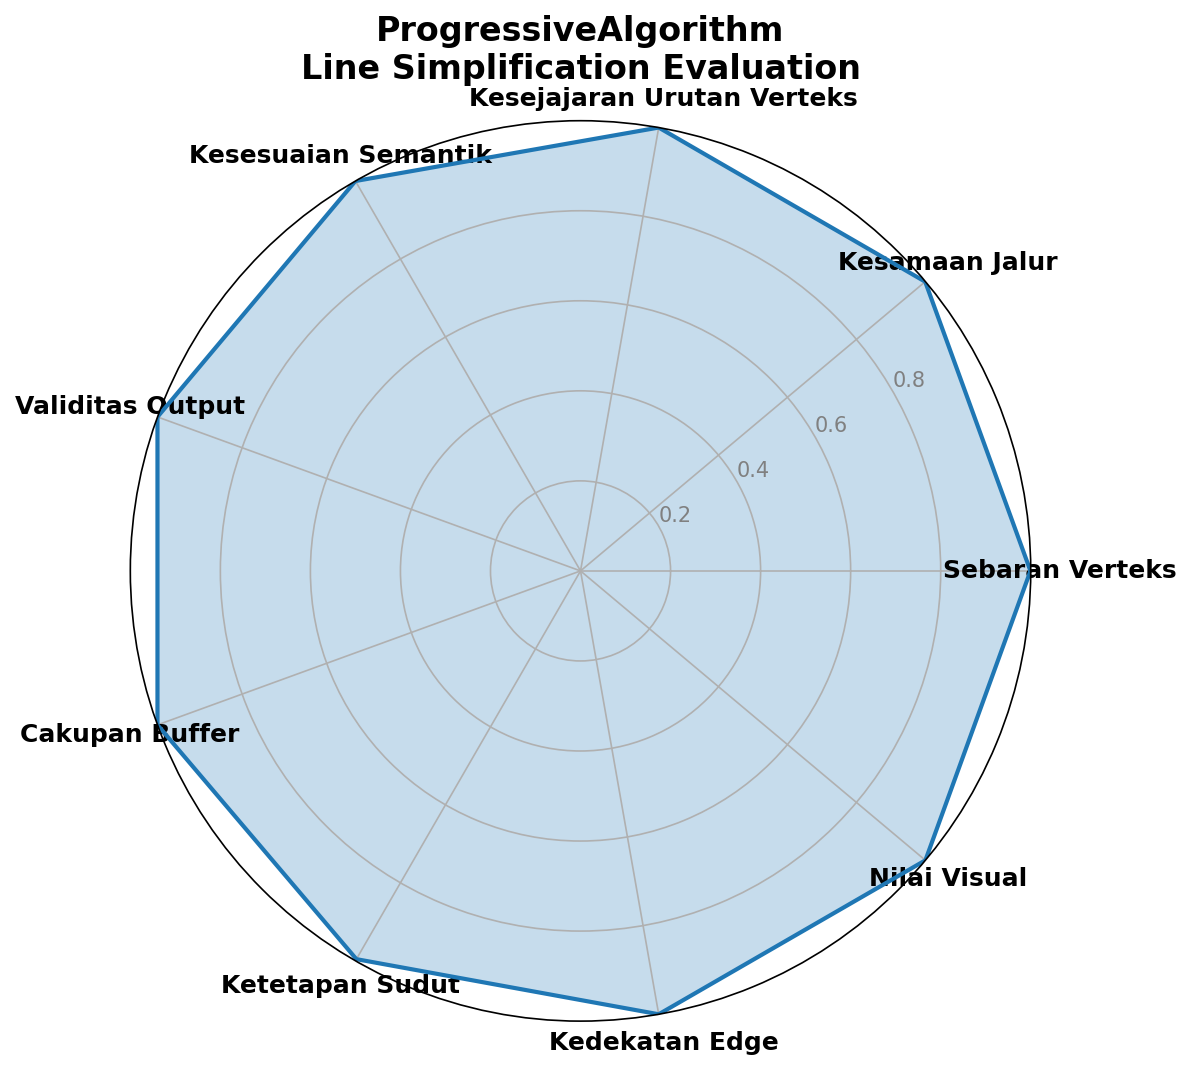




🔹 CircleAlgorithm - Raw Metrics:
   hausdorff: 88.6766
   frechet: 88.6942
   dtw: 8084.6131
   semantic: 0.0930
   topology: 1.0000
   segment_hausdorff: 43.1400
   circular_coverage: 0.9860
   angular_retention: 0.0606
   visual_consistency: 0.5967

📊 CircleAlgorithm - Normalized Radar Scores:
   hausdorff: 0.919
   frechet: 0.919
   dtw: 0.931
   semantic: 0.093
   topology: 1.000
   segment_hausdorff: 0.864
   circular_coverage: 0.986
   angular_retention: 0.061
   visual_consistency: 0.333



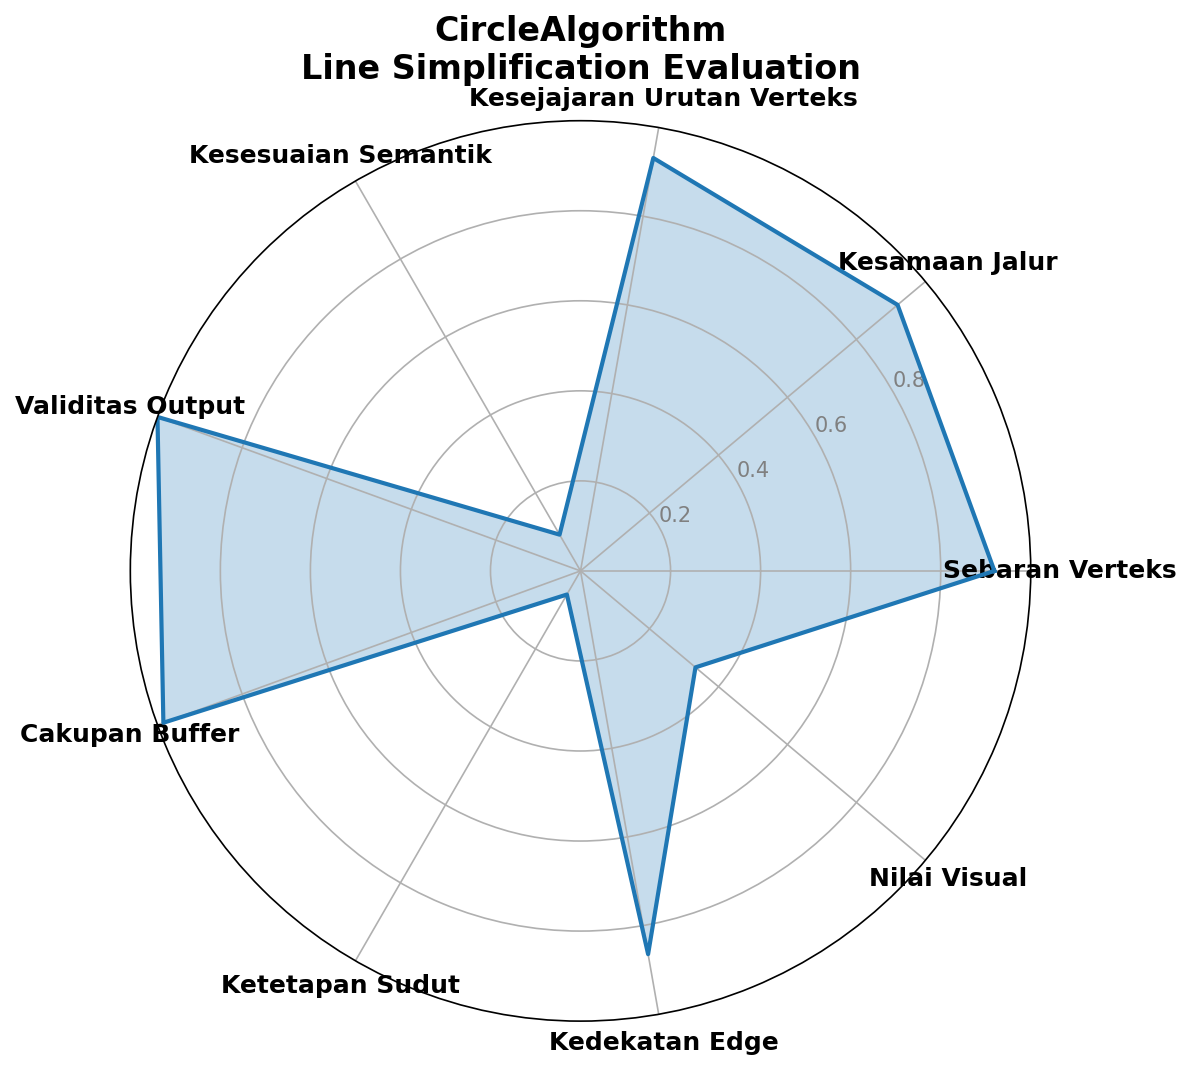




🔹 AngleAlgorithm - Raw Metrics:
   hausdorff: 732.7133
   frechet: 733.0103
   dtw: 78469.2403
   semantic: 0.0277
   topology: 0.9990
   segment_hausdorff: 212.0901
   circular_coverage: 0.4659
   angular_retention: 0.0000
   visual_consistency: 0.0000

📊 AngleAlgorithm - Normalized Radar Scores:
   hausdorff: 0.333
   frechet: 0.333
   dtw: 0.333
   semantic: 0.028
   topology: 0.999
   segment_hausdorff: 0.333
   circular_coverage: 0.466
   angular_retention: 0.000
   visual_consistency: 1.000



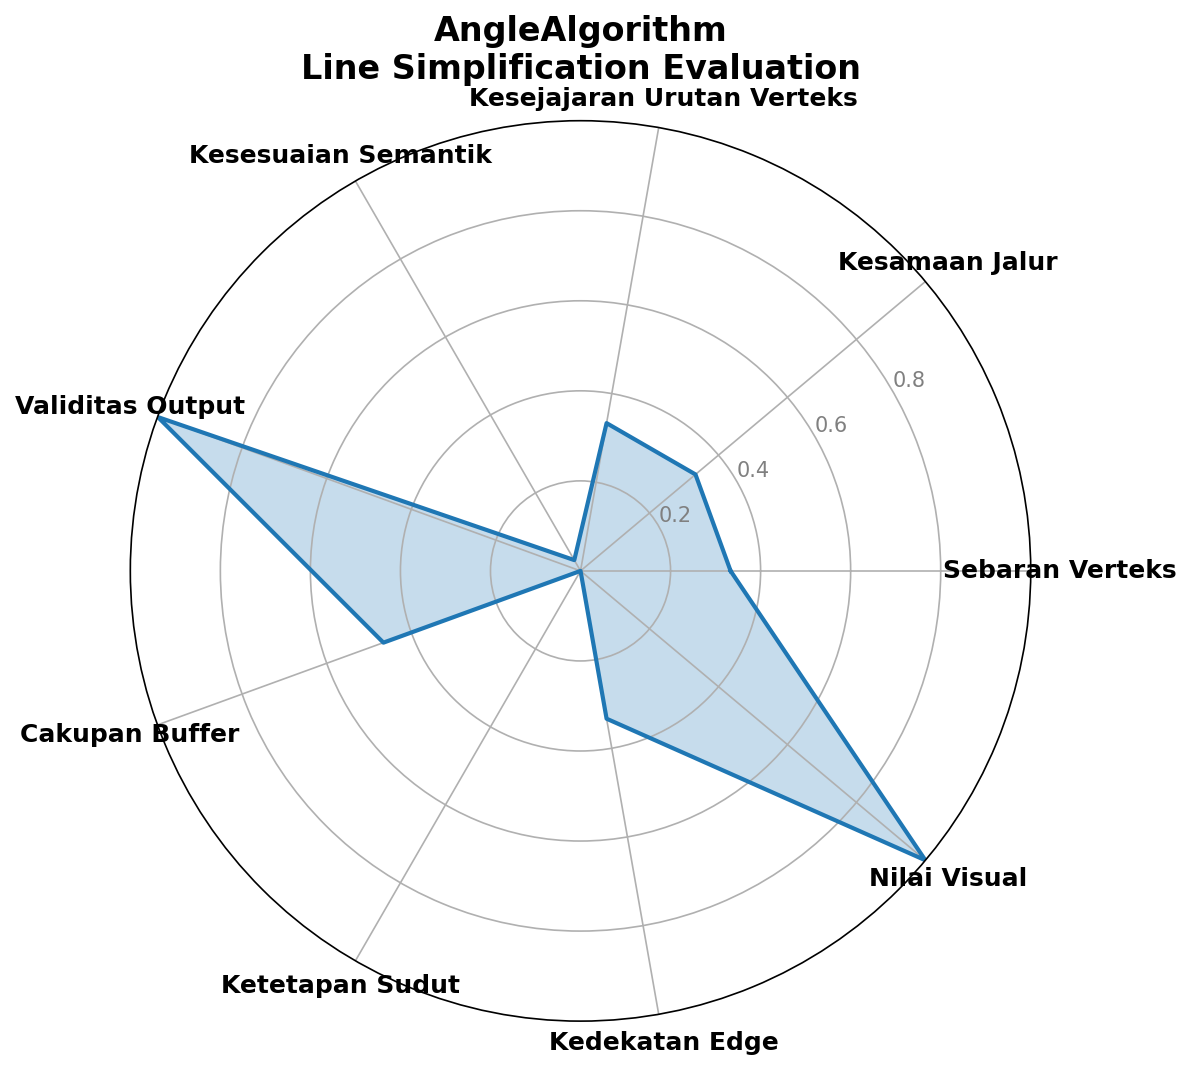




🔹 ReumannWitkam - Raw Metrics:
   hausdorff: 91.0190
   frechet: 91.0571
   dtw: 8109.2246
   semantic: 0.0923
   topology: 1.0000
   segment_hausdorff: 44.3154
   circular_coverage: 0.9842
   angular_retention: 0.0609
   visual_consistency: 0.5760

📊 ReumannWitkam - Normalized Radar Scores:
   hausdorff: 0.917
   frechet: 0.917
   dtw: 0.931
   semantic: 0.092
   topology: 1.000
   segment_hausdorff: 0.861
   circular_coverage: 0.984
   angular_retention: 0.061
   visual_consistency: 0.356



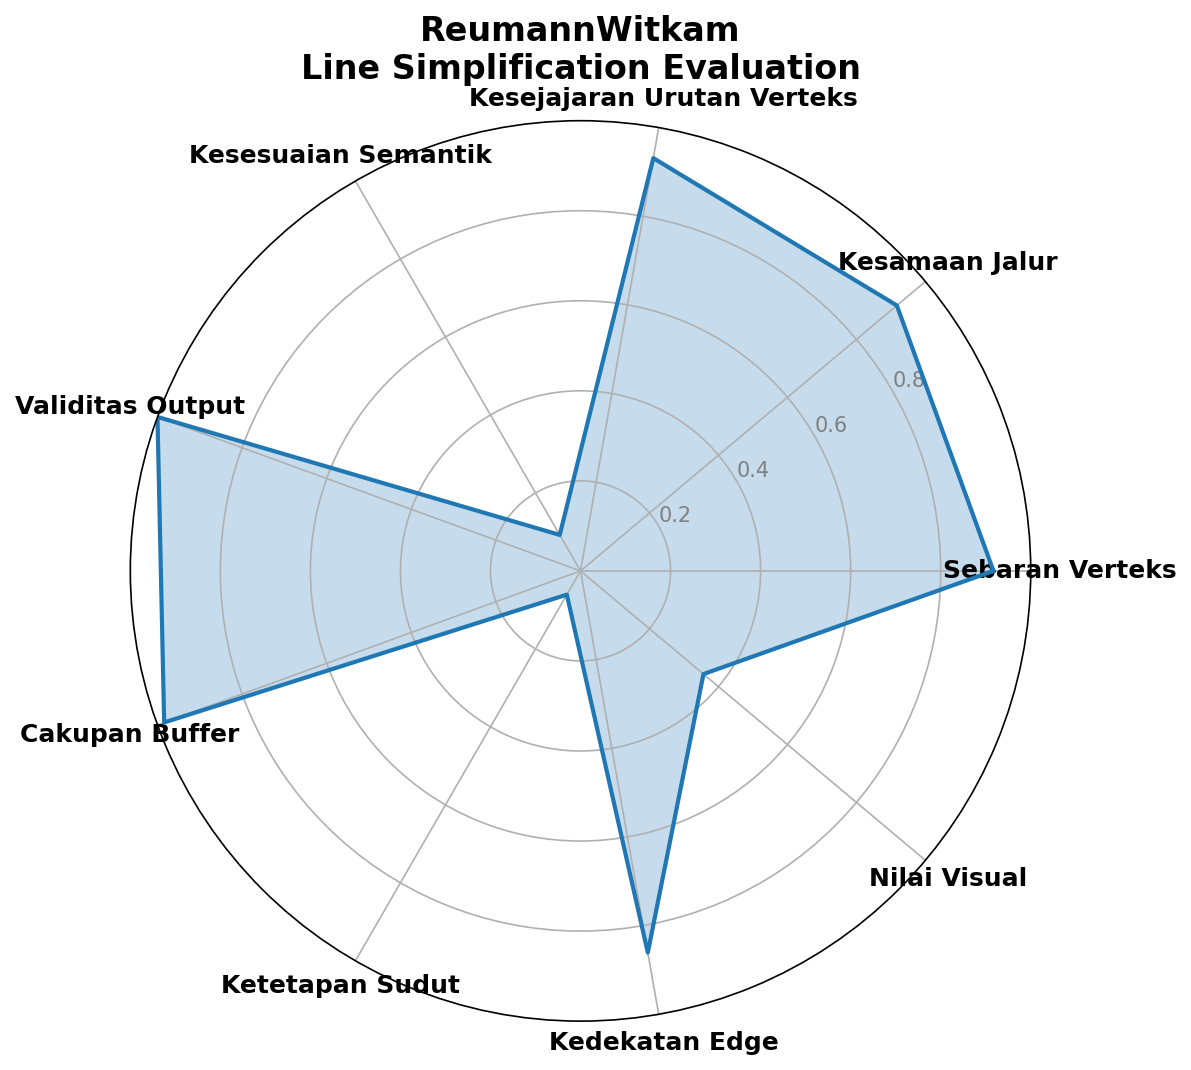




🔹 LangSimplification - Raw Metrics:
   hausdorff: 31.6176
   frechet: 31.6187
   dtw: 1266.7041
   semantic: 0.3316
   topology: 1.0000
   segment_hausdorff: 6.8574
   circular_coverage: 1.0000
   angular_retention: 0.3306
   visual_consistency: 0.1235

📊 LangSimplification - Normalized Radar Scores:
   hausdorff: 0.971
   frechet: 0.971
   dtw: 0.989
   semantic: 0.332
   topology: 1.000
   segment_hausdorff: 0.978
   circular_coverage: 1.000
   angular_retention: 0.331
   visual_consistency: 0.862



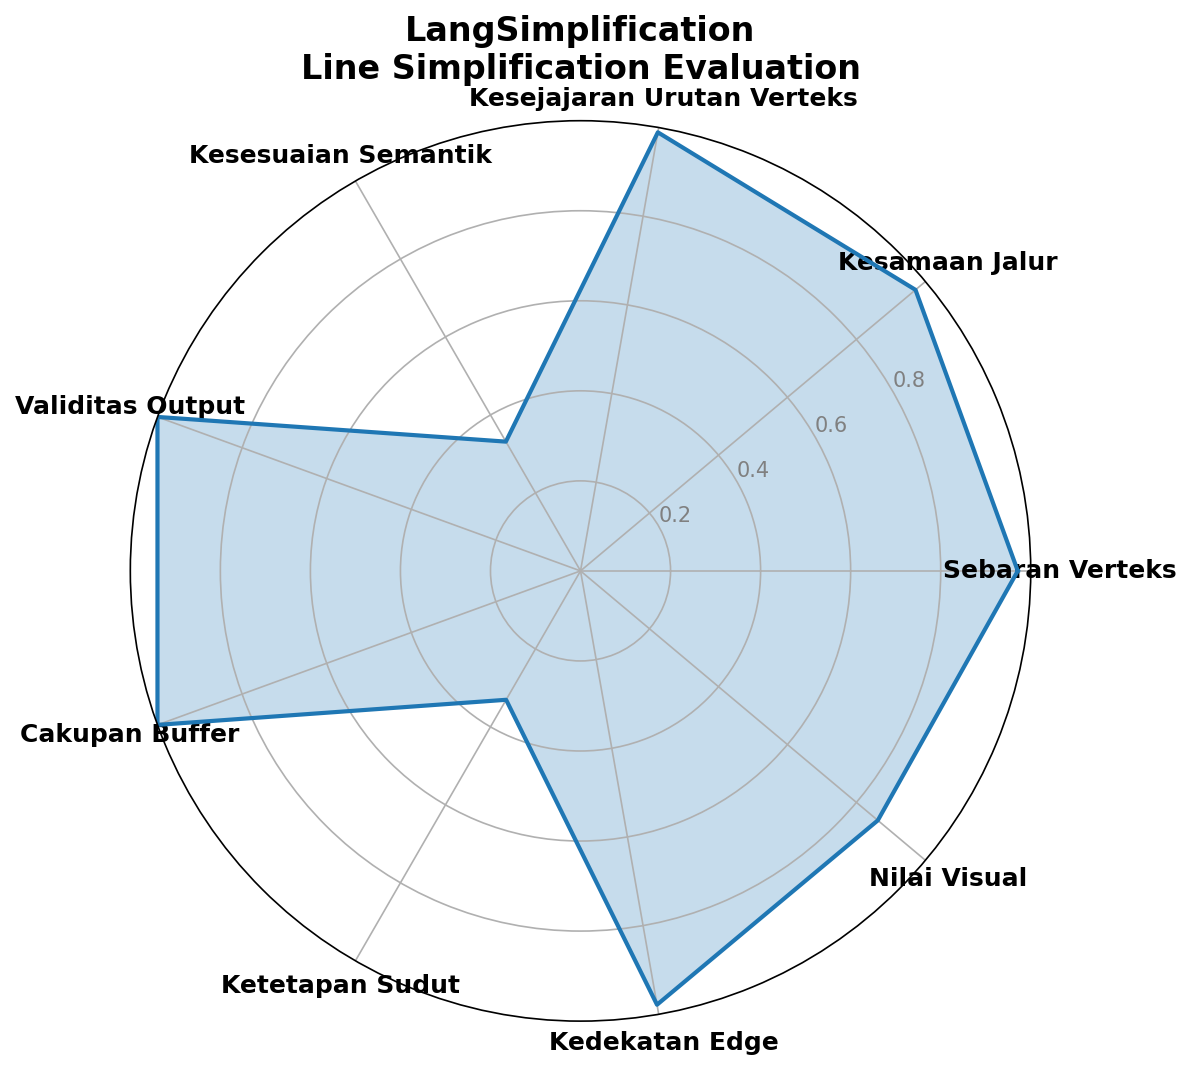




🔹 SleeveFitting - Raw Metrics:
   hausdorff: 366.5361
   frechet: 366.7222
   dtw: 32214.4182
   semantic: 0.0544
   topology: 1.0000
   segment_hausdorff: 106.7222
   circular_coverage: 0.7625
   angular_retention: 0.0361
   visual_consistency: 0.0000

📊 SleeveFitting - Normalized Radar Scores:
   hausdorff: 0.667
   frechet: 0.666
   dtw: 0.726
   semantic: 0.054
   topology: 1.000
   segment_hausdorff: 0.665
   circular_coverage: 0.763
   angular_retention: 0.036
   visual_consistency: 1.000



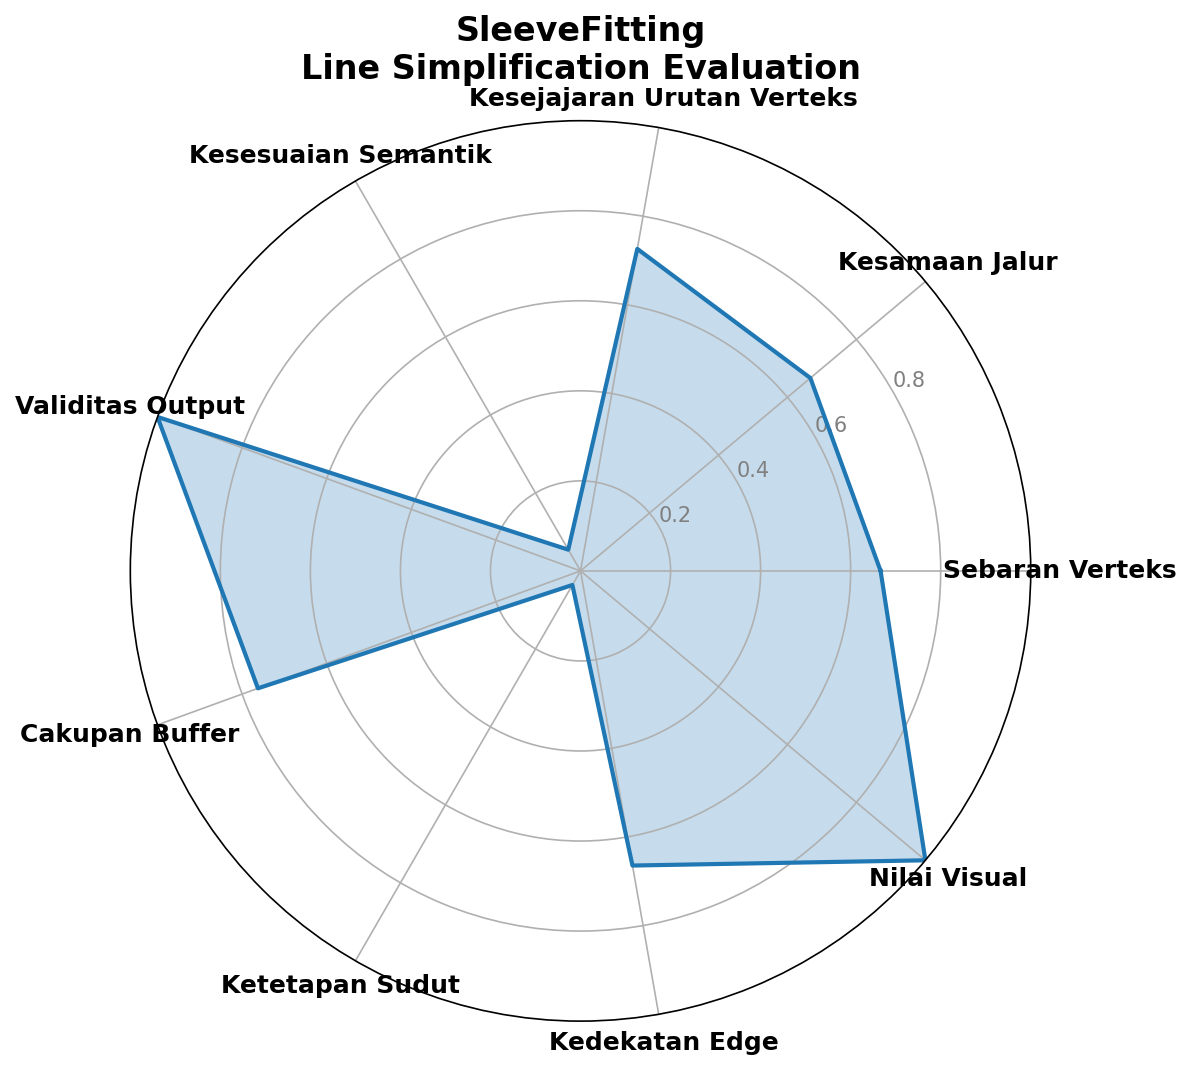




🔹 LiOpenshaw - Raw Metrics:
   hausdorff: 78.1454
   frechet: 78.1975
   dtw: 8298.7208
   semantic: 0.0000
   topology: 1.0000
   segment_hausdorff: 57.6658
   circular_coverage: 0.9746
   angular_retention: 0.0000
   visual_consistency: 0.2811

📊 LiOpenshaw - Normalized Radar Scores:
   hausdorff: 0.929
   frechet: 0.929
   dtw: 0.929
   semantic: 0.000
   topology: 1.000
   segment_hausdorff: 0.819
   circular_coverage: 0.975
   angular_retention: 0.000
   visual_consistency: 0.686



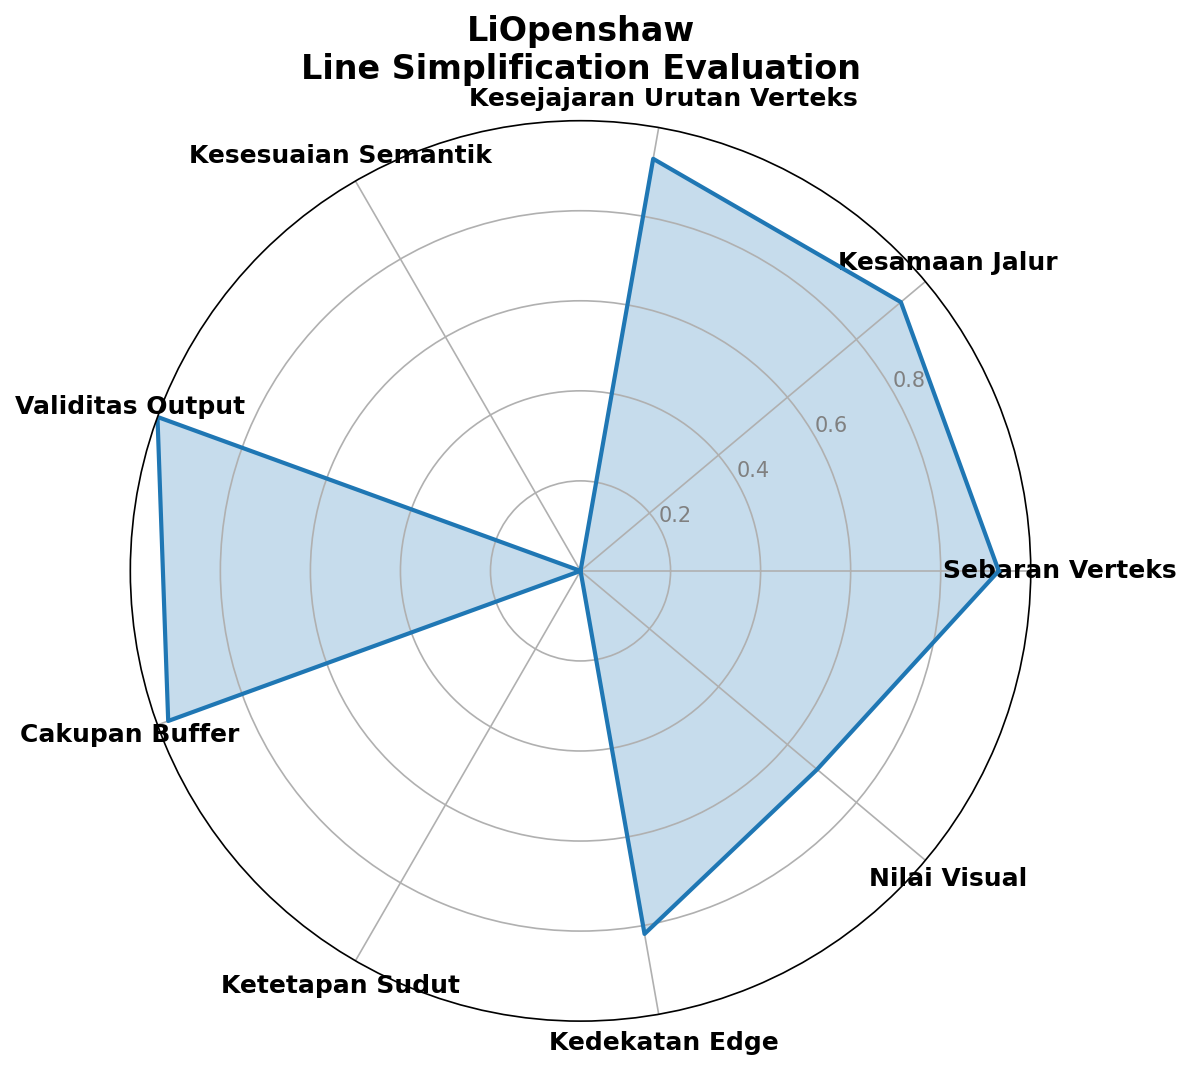

In [8]:
def normalize_metrics_for_radar(metrics_dict, global_max_dist, distance_scale_factor=1.5):
    normalized = metrics_dict.copy()
    
    invert_metrics = ['hausdorff', 'frechet', 'dtw', 'segment_hausdorff', 'visual_consistency']
    for metric in invert_metrics:
        if metric in normalized:
            raw_val = normalized[metric]

            max_val = global_max_dist.get(metric, 1e-6)
            max_val = max(max_val, 1e-6)
            
            normalized[metric] = 1.0 - min(raw_val / (max_val * distance_scale_factor), 1.0)
            normalized[metric] = max(0.0, normalized[metric])
    
    direct_metrics = ['semantic', 'circular_coverage', 'angular_retention', 'topology']
    for metric in direct_metrics:
        if metric in normalized:
            normalized[metric] = min(1.0, max(0.0, normalized[metric]))
    
    return normalized

def display_algorithm_radar_chart(algorithm_name, metrics_dict):
    categories = ['Sebaran Verteks', 'Kesamaan Jalur', 'Kesejajaran Urutan Verteks', 'Kesesuaian Semantik', 'Validitas Output', 'Cakupan Buffer', 'Ketetapan Sudut', 'Kedekatan Edge', 'Nilai Visual']
    
    values = []
    metric_mapping = {
        'Sebaran Verteks': 'hausdorff',
        'Kesamaan Jalur': 'frechet', 
        'Kesejajaran Urutan Verteks': 'dtw',
        'Kesesuaian Semantik': 'semantic',
        'Validitas Output': 'topology',
        'Cakupan Buffer': 'circular_coverage',
        'Ketetapan Sudut': 'angular_retention',
        'Kedekatan Edge': 'segment_hausdorff',
        'Nilai Visual': 'visual_consistency'
    }
    
    for cat in categories:
        metric_key = metric_mapping[cat]
        values.append(metrics_dict.get(metric_key, 0.0))
    
    values += values[:1]
    
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    plt.xticks(angles[:-1], categories, size=12, weight='bold')
    ax.set_rlabel_position(30)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], 
               color="gray", size=10)
    plt.ylim(0, 1)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#1f77b4')
    ax.fill(angles, values, color='#1f77b4', alpha=0.25)
    
    plt.title(f'{algorithm_name}\nLine Simplification Evaluation', 
              size=16, weight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

def display_all_radar_charts(original_gdf, simplified_gdfs, algorithms):
    all_raw = {}
    for algo in algorithms:
        if algo in simplified_gdfs:
            all_raw[algo] = calc_all_metrics(original_gdf, simplified_gdfs[algo])

    invert_keys = ['hausdorff', 'frechet', 'dtw', 'segment_hausdorff', 'visual_consistency']
    global_max = {k: 1e-6 for k in invert_keys}
    for algo_metrics in all_raw.values():
        for k in invert_keys:
            if k in algo_metrics:
                global_max[k] = max(global_max[k], algo_metrics[k])
    
    for algo in algorithms:
        if algo in all_raw:
            raw_metrics = all_raw[algo]
            print(f"🔹 {algo} - Raw Metrics:")
            for k, v in raw_metrics.items():
                print(f"   {k}: {v:.4f}")
                
            normalized = normalize_metrics_for_radar(raw_metrics, global_max, distance_scale_factor=1.5)
            print(f"\n📊 {algo} - Normalized Radar Scores:")
            for k, v in normalized.items():
                print(f"   {k}: {v:.3f}")
            print()
            
            display_algorithm_radar_chart(algo, normalized)
            print("="*80)
            # print(f"Raw metrics:")
            # print(f"  Hausdorff: {raw_metrics['hausdorff']:.2f}")
            # print(f"  Fréchet: {raw_metrics['frechet']:.2f}")
            # print(f"  DTW: {raw_metrics['dtw']:.2f}")
            # print(f"  Semantic: {raw_metrics['semantic']:.3f}")
            # print(f"  Topology: {raw_metrics['topology']:.3f}")
            # print(f"  Circular Buffer: {raw_metrics.get('circular_buffer', 0):.3f}")
            # print(f"  Angular Retention: {raw_metrics.get('angular_retention', 0):.3f}")
            # print(f"  Segment Hausdorff: {raw_metrics.get('segment_hausdorff', 0):.3f}")
            
            # normalized_metrics = normalize_metrics_for_radar(raw_metrics, 1.5)
            
            # print(f"Normalized metrics:")
            # for metric, value in normalized_metrics.items():
            #     print(f"  {metric}: {value:.3f}")
            
            # display_algorithm_radar_chart(algo, normalized_metrics)

            print()
            if algo != algorithms[-1]:
                print("\n" + "="*80 + "\n")
        else:
            print(f"{algo} not found")

display_all_radar_charts(original_gdf, simplified_gdfs, algorithms)